In [110]:
import pandas as pd
import numpy as np
from datetime import timedelta
import datetime
from pytz import timezone, utc
from timezonefinder import TimezoneFinder
import geopy.distance
import matplotlib.pyplot as plt
import math
import geopandas as gpd
import pyproj
from geojson import Point, LineString, Feature, FeatureCollection, dump

plt.rcParams['font.size'] = '20'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 999)


# AIR TRAVEL (2015-)

In [111]:
ROOT_DIR = '/Users/alexanderguo/Documents/github/frontend/flightlog/'
df = pd.read_csv(ROOT_DIR + 'flightlog.csv')
airports = pd.read_csv(ROOT_DIR + 'airports.csv')

tf = TimezoneFinder()

def get_offset(t, lat, lng):
    """
    returns a location's time zone offset from UTC in hours.
    """
    tz_target = timezone(tf.certain_timezone_at(lng=lng, lat=lat))
    today_target = tz_target.localize(t)
    today_utc = utc.localize(t)
    return (today_utc - today_target).total_seconds() / 3600

# Main processing

In [112]:
# Merge with airports CSV
df = df.merge(airports[['Name', 'City', 'Country', 'IATA', 'Lat', 'Long']], 
              left_on='Dep Airport', right_on='IATA', how='left')
df = df.drop(columns='IATA').rename(columns={'Name': 'Dep Name', 
                                             'Lat': 'Dep Lat', 
                                             'Long': 'Dep Long', 
                                             'City': 'Dep City', 
                                             'Country': 'Dep Country'})
df = df.merge(airports[['Name', 'City', 'Country', 'IATA', 'Lat', 'Long']], 
              left_on='Arr Airport', right_on='IATA', how='left')
df = df.drop(columns='IATA').rename(columns={'Name': 'Arr Name', 
                                             'Lat': 'Arr Lat', 
                                             'Long': 'Arr Long', 
                                             'City': 'Arr City', 
                                             'Country': 'Arr Country'})

In [113]:
# Date cleaning


DATETIME_COLS = ['Scheduled Dep Time (Local)', 
                 'Scheduled Arr Time (Local)', 
                 'Actual Dep Time (Local)', 
                 'Actual Arr Time (Local)']
important_cols = ['Date', 
                  'Scheduled Dep Time (Local)', 
                  'Scheduled Arr Time (Local)', 
                  'Actual Duration', 
                  'Airline', 
                  'Flight', 
                  'Dep Airport', 
                  'Arr Airport', 
                  'Distance', 
                  'Dep Delay (min)', 
                  'Dep Delay (min)', 
                  'Class', 
                  'Aircraft', 
                  'Registration']



df['Date'] = pd.to_datetime(df['Date'])

# Convert times to datetime object with offset from (+1) if needed.
# Note: minus not supported.
for col in DATETIME_COLS:
    for i, r in df.iterrows():
        time = str(r[col])
        if not pd.isna(r[col]):
            datetime_str = r['Date'].strftime('%Y-%m-%d') + ' ' + time.split('+')[0]
            days_offset = 0 if '+' not in time else int(time.split('+')[1])
            df.loc[i, col] = pd.to_datetime(datetime_str) + pd.Timedelta(days=days_offset)
    df[col] = pd.to_datetime(df[col])
# Set actual for future flights.
df['Actual Dep Time (Local)'] = df['Actual Dep Time (Local)'].fillna(df['Scheduled Dep Time (Local)'])
df['Actual Arr Time (Local)'] = df['Actual Arr Time (Local)'].fillna(df['Scheduled Arr Time (Local)'])


# Get departure and arrival time zones.
df['Dep Timezone'] = df[['Dep Lat', 'Dep Long']].apply(
    lambda r: timezone(tf.certain_timezone_at(lng=r['Dep Long'], lat=r['Dep Lat'])), axis=1)
df['Arr Timezone'] = df[['Arr Lat', 'Arr Long']].apply(
    lambda r: timezone(tf.certain_timezone_at(lng=r['Arr Long'], lat=r['Arr Lat'])), axis=1)

# Calculate times in UTC.
# Known error for Jordan (appears time zone is equivalent to Cairo tome)
for col in DATETIME_COLS:
    utc_col = col.split('(')[0] + '(UTC)'
    dep_or_arr = 'Dep' if 'Dep' in col else 'Arr'
    for i, r in df.iterrows():
        hours_offset = get_offset(datetime.datetime.strptime(
            r[col].strftime("%m/%d/%Y, %H:%M:%S"), "%m/%d/%Y, %H:%M:%S"), 
                                  r[dep_or_arr + ' Lat'], r[dep_or_arr + ' Long']);
        df.loc[i, utc_col] = r[col] - timedelta(hours=hours_offset)
    

# Calculate actual durations
for col in ['Scheduled Duration', 'Actual Duration']:
    df[col] = df[col.split(' ')[0] + ' Arr Time (UTC)'] - df[col.split(' ')[0] + ' Dep Time (UTC)']
    df[col + ' (min)'] = df[col].dt.total_seconds() / 60
    
# Do duration checking.
for i, r in df.iterrows():
    if r['Actual Duration (min)'] < 0 or r['Actual Duration (min)'] > 1440 or r['Scheduled Duration (min)'] < 0 or r['Scheduled Duration (min)'] > 1440:
        print('Please check this row, the duration is wrong', r)
        raise ValueError('Duration error')

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3542269883.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [114]:
# Add some extra columns

df['Distance'] = df.apply(lambda row: geopy.distance.distance((row['Dep Lat'], row['Dep Long']), (row['Arr Lat'], row['Arr Long'])).miles, axis=1).round().astype(int)
df['Dep Delay'] = df['Actual Dep Time (UTC)'] - df['Scheduled Dep Time (UTC)']
df['Arr Delay'] = df['Actual Arr Time (UTC)'] - df['Scheduled Arr Time (UTC)']
for i, r in df.iterrows():
    df.loc[i, 'Dep Delay (min)'] = r['Dep Delay'].seconds//60 if r['Dep Delay'].days >= 0 else r['Dep Delay'].seconds//60-1440
    df.loc[i, 'Arr Delay (min)'] = r['Arr Delay'].seconds//60 if r['Arr Delay'].days >= 0 else r['Arr Delay'].seconds//60-1440
    df.loc[i, 'Domestic/International'] = 'International' if r['Dep Country'] != r['Arr Country'] else 'Domestic'
    if i > 0:
        df.loc[i, 'Last flight arrival (UTC)'] = df.loc[i-1, 'Actual Arr Time (UTC)']
        df.loc[i, 'Time since last flight'] = r['Actual Dep Time (UTC)'] - df.loc[i, 'Last flight arrival (UTC)']

df['Minutes Made Up'] = df['Dep Delay (min)'] - df['Arr Delay (min)']

current_datetime_utc = pd.Timestamp.utcnow().tz_convert('UTC')
past_df = df[df['Scheduled Arr Time (UTC)'].dt.tz_localize('UTC') <= current_datetime_utc]
future_df = df[df['Scheduled Arr Time (UTC)'].dt.tz_localize('UTC') > current_datetime_utc]
past_df.head()

,Date,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Dep Time (Local),Actual Arr Time (Local),Airline,Flight,Dep Airport,Arr Airport,Class,Aircraft,Registration,Arr Connect,Unnamed: 13,Dep Name,Dep City,Dep Country,Dep Lat,Dep Long,Arr Name,Arr City,Arr Country,Arr Lat,Arr Long,Dep Timezone,Arr Timezone,Scheduled Dep Time (UTC),Scheduled Arr Time (UTC),Actual Dep Time (UTC),Actual Arr Time (UTC),Scheduled Duration,Scheduled Duration (min),Actual Duration,Actual Duration (min),Distance,Dep Delay,Arr Delay,Dep Delay (min),Arr Delay (min),Domestic/International,Last flight arrival (UTC),Time since last flight,Minutes Made Up
0,2015-01-03,2015-01-03 13:45:00,2015-01-03 14:10:00,2015-01-03 13:55:00,2015-01-03 14:29:00,Hainan,HU481,PEK,BOS,Economy,NaN,NaN,NaN,NaN,Beijing Capital International Airport,Beijing,China,40.080101,116.584999,General Edward Lawrence Logan International Ai...,Boston,United States,42.364300,-71.005203,Asia/Manila,America/New_York,2015-01-03 05:45:00,2015-01-03 19:10:00,2015-01-03 05:55:00,2015-01-03 19:29:00,0 days 13:25:00,805.0,0 days 13:34:00,814.0,6737,0 days 00:10:00,0 days 00:19:00,10.0,19.0,International,NaT,NaT,-9.0
1,2015-03-08,2015-03-08 08:34:00,2015-03-08 10:01:00,2015-03-08 08:52:00,2015-03-08 09:42:00,United,UA1711,BOS,EWR,Recliner First,B738,N54241,1.0,NaN,General Edward Lawrence Logan International Ai...,Boston,United States,42.364300,-71.005203,Newark Liberty International Airport,New York,United States,40.692501,-74.168701,America/New_York,America/New_York,2015-03-08 12:34:00,2015-03-08 14:01:00,2015-03-08 12:52:00,2015-03-08 13:42:00,0 days 01:27:00,87.0,0 days 00:50:00,50.0,201,0 days 00:18:00,-1 days +23:41:00,18.0,-19.0,Domestic,2015-01-03 19:29:00,63 days 17:23:00,37.0
2,2015-03-08,2015-03-08 12:55:00,2015-03-09 15:00:00,2015-03-08 13:40:00,2015-03-09 15:10:00,United,UA89,EWR,PEK,Economy,B772,N78005,NaN,NaN,Newark Liberty International Airport,New York,United States,40.692501,-74.168701,Beijing Capital International Airport,Beijing,China,40.080101,116.584999,America/New_York,Asia/Manila,2015-03-08 16:55:00,2015-03-09 07:00:00,2015-03-08 17:40:00,2015-03-09 07:10:00,0 days 14:05:00,845.0,0 days 13:30:00,810.0,6831,0 days 00:45:00,0 days 00:10:00,45.0,10.0,International,2015-03-08 13:42:00,0 days 03:58:00,35.0
3,2015-03-19,2015-03-19 17:00:00,2015-03-19 18:45:00,2015-03-19 17:24:00,2015-03-19 18:15:00,United,UA88,PEK,EWR,Economy,B772,N78005,1.0,NaN,Beijing Capital International Airport,Beijing,China,40.080101,116.584999,Newark Liberty International Airport,New York,United States,40.692501,-74.168701,Asia/Manila,America/New_York,2015-03-19 09:00:00,2015-03-19 22:45:00,2015-03-19 09:24:00,2015-03-19 22:15:00,0 days 13:45:00,825.0,0 days 12:51:00,771.0,6831,0 days 00:24:00,-1 days +23:30:00,24.0,-30.0,International,2015-03-09 07:10:00,10 days 02:14:00,54.0
4,2015-03-19,2015-03-19 20:32:00,2015-03-19 21:46:00,2015-03-19 21:21:00,2015-03-19 22:03:00,United,UA1409,EWR,BOS,Economy,B734,N87512,NaN,NaN,Newark Liberty International Airport,New York,United States,40.692501,-74.168701,General Edward Lawrence Logan International Ai...,Boston,United States,42.364300,-71.005203,America/New_York,America/New_York,2015-03-20 00:32:00,2015-03-20 01:46:00,2015-03-20 01:21:00,2015-03-20 02:03:00,0 days 01:14:00,74.0,0 days 00:42:00,42.0,201,0 days 00:49:00,0 days 00:17:00,49.0,17.0,Domestic,2015-03-19 22:15:00,0 days 03:06:00,32.0


In [115]:
# Calculate totals

TOTAL_DIST = df['Distance'].sum()
TOTAL_TIME = df['Actual Duration (min)'].sum()
NUM_FLIGHTS = df['Date'].count()
NUM_AIRLINES = df['Airline'].nunique()
NUM_COUNTRIES = len(set(df['Dep Country'].tolist()) | set(df['Arr Country'].tolist()))
NUM_AIRPORTS = len(set(df['Dep Airport'].tolist()) | set(df['Arr Airport'].tolist()))

TOTAL_DIST_PAST = past_df['Distance'].sum()
TOTAL_TIME_PAST = past_df['Actual Duration (min)'].sum()
NUM_FLIGHTS_PAST = past_df['Date'].count()

TOTAL_DIST_FUTURE = future_df['Distance'].sum()
TOTAL_TIME_FUTURE = future_df['Actual Duration (min)'].sum()
NUM_FLIGHTS_FUTURE = future_df['Date'].count()

sorted_by_flight_interval = df.sort_values('Time since last flight', ascending=False).reset_index()
LONGEST_INTERVAL = str(sorted_by_flight_interval.loc[0, 'Time since last flight'])
LONGEST_INTERVAL_0 = str(sorted_by_flight_interval.loc[0, 'Last flight arrival (UTC)'].date())
LONGEST_INTERVAL_1 = str(sorted_by_flight_interval.loc[0, 'Scheduled Dep Time (UTC)'].date())
sorted_by_flight_interval_reverse = df.sort_values('Time since last flight', ascending=True).reset_index()
SHORTEST_INTERVAL = str(sorted_by_flight_interval_reverse.loc[0, 'Time since last flight'])
SHORTEST_INTERVAL_0 = str(sorted_by_flight_interval_reverse.loc[0, 'Last flight arrival (UTC)'].date())
SHORTEST_INTERVAL_1 = str(sorted_by_flight_interval_reverse.loc[0, 'Scheduled Dep Time (UTC)'].date())


print('Total Distance Flown (miles): ' + str(TOTAL_DIST))
print('Total time in the air: ' + str(timedelta(minutes=int(TOTAL_TIME))))
print('Total Flights: ' + str(NUM_FLIGHTS))
print('Number of Airlines: ' + str(NUM_AIRLINES))
print('Number of Countries: ' + str(NUM_COUNTRIES))
print('Number of Airports: ' + str(NUM_AIRPORTS))
print('Longest time without flying: ' + LONGEST_INTERVAL + ', ' + LONGEST_INTERVAL_0 + ' to ' + LONGEST_INTERVAL_1)

print('')
print('Past Distance Flown (miles): ' + str(TOTAL_DIST_PAST))
print('Past time in the air: ' + str(timedelta(minutes=int(TOTAL_TIME_PAST))))
print('Past Flights: ' + str(NUM_FLIGHTS_PAST))

print('')
print('Future Distance Flown (miles): ' + str(TOTAL_DIST_FUTURE))
print('Future time in the air: ' + str(timedelta(minutes=int(TOTAL_TIME_FUTURE))))
print('Future Flights: ' + str(NUM_FLIGHTS_FUTURE))

df.to_csv('full_df.csv')


Total Distance Flown (miles): 788965
Total time in the air: 67 days, 15:27:00
Total Flights: 360
Number of Airlines: 58
Number of Countries: 43
Number of Airports: 131
Longest time without flying: 157 days 18:22:00, 2016-07-10 to 2016-12-15

Past Distance Flown (miles): 785349
Past time in the air: 67 days, 5:27:00
Past Flights: 356

Future Distance Flown (miles): 3616
Future time in the air: 10:00:00
Future Flights: 4


# FLIGHTS SORTED BY DISTANCE

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3076179783.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False)


,Dep Airport,Arr Airport,Dep Country,Arr Country,Distance_x,Date_y,Distance_y
0,SIN,SFO,Singapore,United States,8446,3,25338
1,EWR,CPT,United States,South Africa,7817,1,7817
2,SYD,LAX,Australia,United States,7488,1,7488
3,PVG,BOS,China,United States,7308,2,14616
4,SFO,HKG,United States,Hong Kong,6927,1,6927
5,PEK,IAD,China,United States,6921,3,20763
6,DXB,YYZ,United Arab Emirates,Canada,6899,1,6899
7,EWR,PEK,United States,China,6831,15,102465
8,PEK,BOS,China,United States,6737,4,26948
9,EWR,NRT,United States,Japan,6732,1,6732


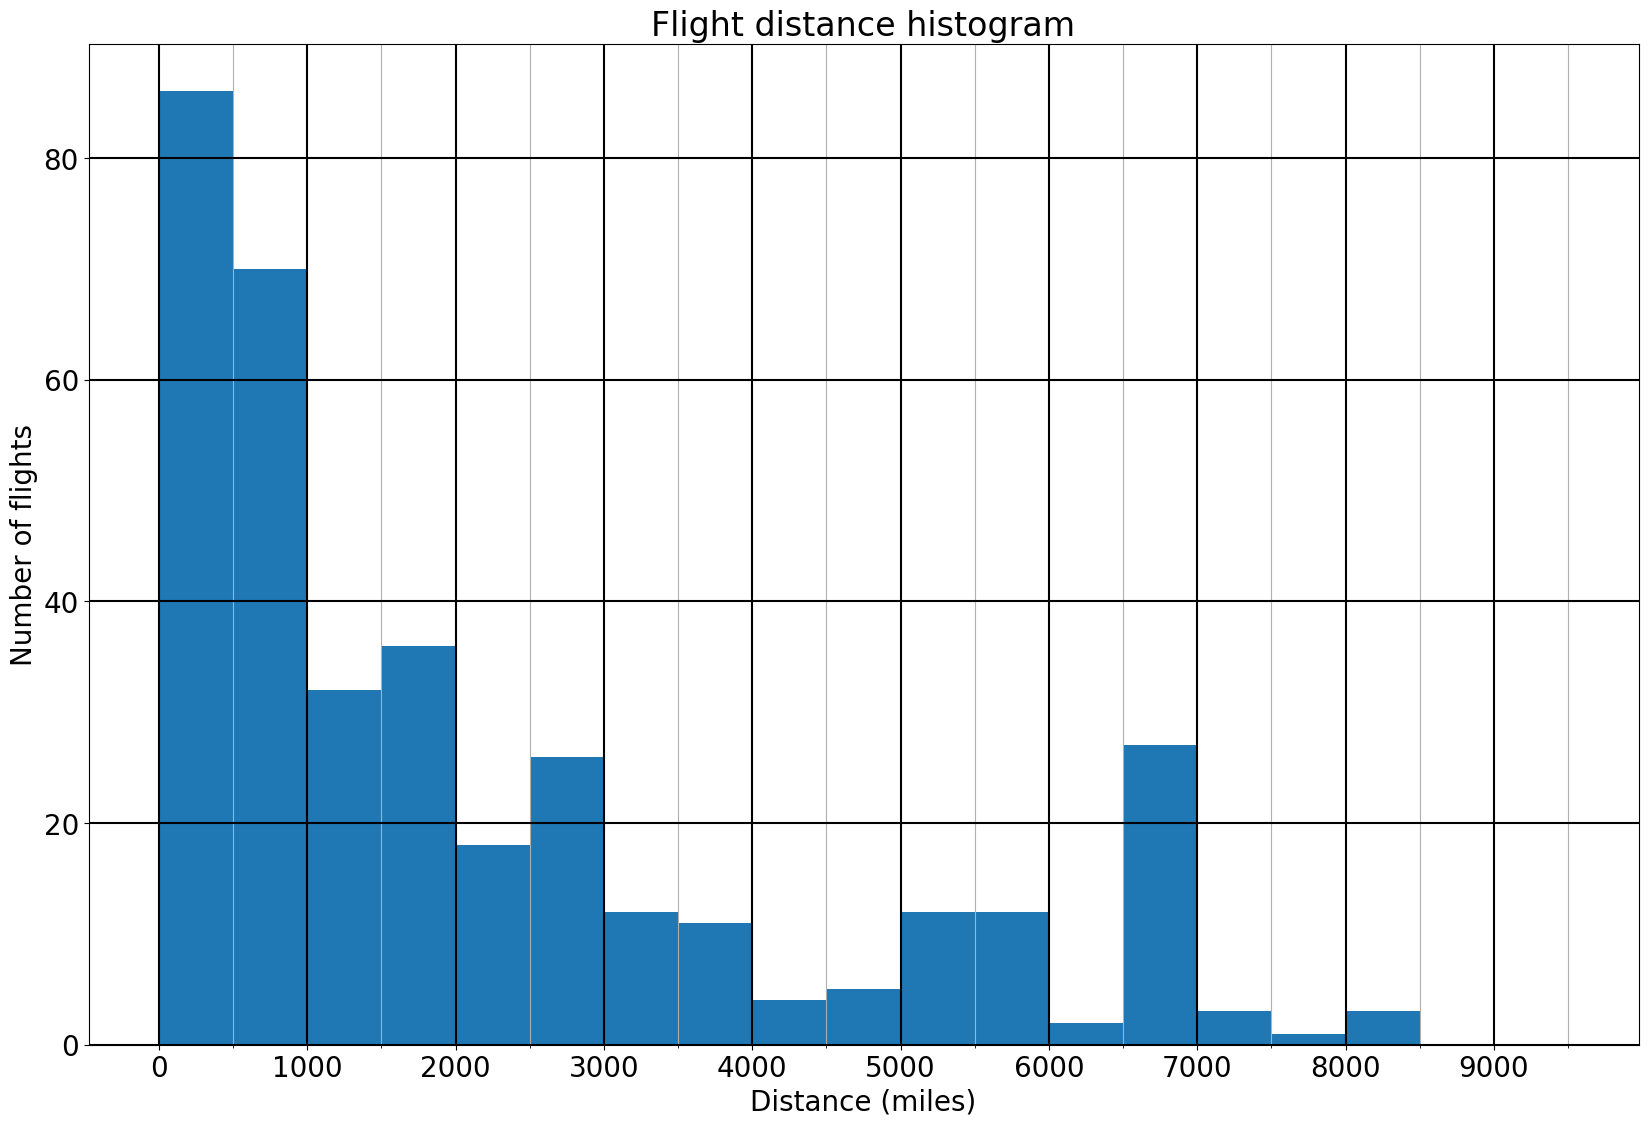

In [116]:
df['Sorted Route'] = df.apply(lambda row: str(sorted([row['Dep Airport'], row['Arr Airport']])[0]) + ' ' + str(sorted([row['Dep Airport'], row['Arr Airport']])[1]), axis=1)
routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False)
route_distance_cols = ['Dep Airport', 'Arr Airport', 'Dep Country', 'Arr Country', 'Distance_x', 'Date_y', 'Distance_y']

fig, ax = plt.subplots(1, 1, figsize=(20,13))
bins = list(range(0, 10000, 500))
ax.hist(df['Distance'], bins=bins)
ax.set_xticks(bins, minor=True)
ax.set_xticks([b for i, b in enumerate(bins) if i%2 == 0])
ax.grid(which='major', linewidth=1.5, color='black')
ax.grid(which='minor', axis='both')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Number of flights')
ax.set_title('Flight distance histogram')
plt.savefig(ROOT_DIR + 'figures/distance_hist.jpg', bbox_inches='tight')

longest_flights = df.sort_values(['Distance'], ascending=False).drop_duplicates(subset='Distance').head(20)
longest_flights = longest_flights.merge(routes_sorted, on='Sorted Route')
longest_flights.reset_index()[route_distance_cols]
                                                                                        


In [117]:
# Shortest flights
shortest_flights = df.sort_values(['Distance'], ascending=True).drop_duplicates(subset='Distance').head(20)
shortest_flights = shortest_flights.merge(routes_sorted, on='Sorted Route')
shortest_flights.reset_index()[route_distance_cols]
                                                     

,Dep Airport,Arr Airport,Dep Country,Arr Country,Distance_x,Date_y,Distance_y
0,PHL,JFK,United States,United States,94,1,94
1,HNL,LIH,United States,United States,102,1,102
2,IAD,PHL,United States,United States,135,1,135
3,IAH,AUS,United States,United States,140,1,140
4,KUL,SIN,Malaysia,Singapore,185,1,185
5,JFK,BOS,United States,United States,187,1,187
6,CDG,SEN,France,United Kingdom,195,2,390
7,LJG,KMG,China,China,199,1,199
8,BOS,EWR,United States,United States,201,26,5226
9,AMS,LCY,Netherlands,United Kingdom,209,1,209


In [118]:
# Longest domestic
longest_domestic = df[df['Domestic/International']=='Domestic'].sort_values('Distance', ascending=False).drop_duplicates(subset='Distance').head(30)
longest_domestic = longest_domestic.merge(routes_sorted, on='Sorted Route')
longest_domestic.reset_index()[route_distance_cols]


,Dep Airport,Arr Airport,Dep Country,Arr Country,Distance_x,Date_y,Distance_y
0,OGG,EWR,United States,United States,4903,1,4903
1,ORD,HNL,United States,United States,4244,1,4244
2,HNL,IAH,United States,United States,3904,1,3904
3,DEN,OGG,United States,United States,3302,1,3302
4,SFO,BOS,United States,United States,2704,9,24336
5,LAX,BOS,United States,United States,2611,3,7833
6,SFO,JFK,United States,United States,2586,3,7758
7,EWR,SFO,United States,United States,2565,6,15390
8,PHL,SFO,United States,United States,2521,2,5042
9,LAX,EWR,United States,United States,2454,1,2454


In [119]:
# Shortest international
shortest_international = df[df['Domestic/International']=='International'].sort_values('Distance', ascending=True).drop_duplicates(subset='Distance').head(20)
shortest_international = shortest_international.merge(routes_sorted, on='Sorted Route')
shortest_international.reset_index()[route_distance_cols]


,Dep Airport,Arr Airport,Dep Country,Arr Country,Distance_x,Date_y,Distance_y
0,KUL,SIN,Malaysia,Singapore,185,1,185
1,CDG,SEN,France,United Kingdom,195,2,390
2,AMS,LCY,Netherlands,United Kingdom,209,1,209
3,CDG,LHR,France,United Kingdom,216,2,432
4,AMM,PFO,Jordan,Cyprus,290,1,290
5,CAI,AMM,Egypt,Jordan,294,1,294
6,LIS,MAD,Portugal,Spain,319,1,319
7,PRG,WAW,Czech Republic,Poland,325,1,325
8,LHR,FRA,United Kingdom,Germany,408,1,408
9,BSL,LGW,France,United Kingdom,426,1,426


# FLIGHTS SORTED BY DURATION

,Date,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Duration,Airline,Flight,Dep Airport,Arr Airport,Distance,Dep Delay (min),Dep Delay (min),Class,Aircraft,Registration
218,2022-11-10,2022-11-10 10:40:00,2022-11-11 20:15:00,0 days 16:09:00,United,UA29,SFO,SIN,8446,50.0,50.0,Economy,B789,N28987
221,2022-11-28,2022-11-28 10:15:00,2022-11-28 08:50:00,0 days 14:33:00,United,UA2,SIN,SFO,8446,13.0,13.0,Economy,B789,N29985
72,2018-01-07,2018-01-07 10:00:00,2018-01-07 08:40:00,0 days 14:09:00,United,UA2,SIN,SFO,8446,20.0,20.0,Lie-flat Business,B789,N38955
354,2026-01-12,2026-01-12 08:25:00,2026-01-12 14:55:00,0 days 14:05:00,Japan,JL45,HND,CDG,6046,21.0,21.0,Lie-flat Business,A35K,JA05WJ
75,2018-03-29,2018-03-29 12:25:00,2018-03-29 14:35:00,0 days 14:03:00,Hainan,HU7961,PVG,BOS,7308,26.0,26.0,Economy,B789,B7835
74,2018-03-22,2018-03-22 16:35:00,2018-03-23 19:20:00,0 days 14:03:00,Hainan,HU7962,BOS,PVG,7308,14.0,14.0,Economy,B788,B2750
98,2019-01-06,2019-01-06 23:55:00,2019-01-07 05:05:00,0 days 13:50:00,Air Canada,AC57,DXB,YYZ,6899,74.0,74.0,Lie-flat Business,B77W,CFRAM
260,2023-09-30,2023-09-30 23:20:00,2023-10-02 05:00:00,0 days 13:35:00,United,UA877,SFO,HKG,6927,34.0,34.0,Economy,B77W,N2747U
0,2015-01-03,2015-01-03 13:45:00,2015-01-03 14:10:00,0 days 13:34:00,Hainan,HU481,PEK,BOS,6737,10.0,10.0,Economy,NaN,NaN
126,2019-12-18,2019-12-18 20:30:00,2019-12-19 18:00:00,0 days 13:33:00,United,UA1122,EWR,CPT,7817,134.0,134.0,Lie-flat Business,B789,N27957


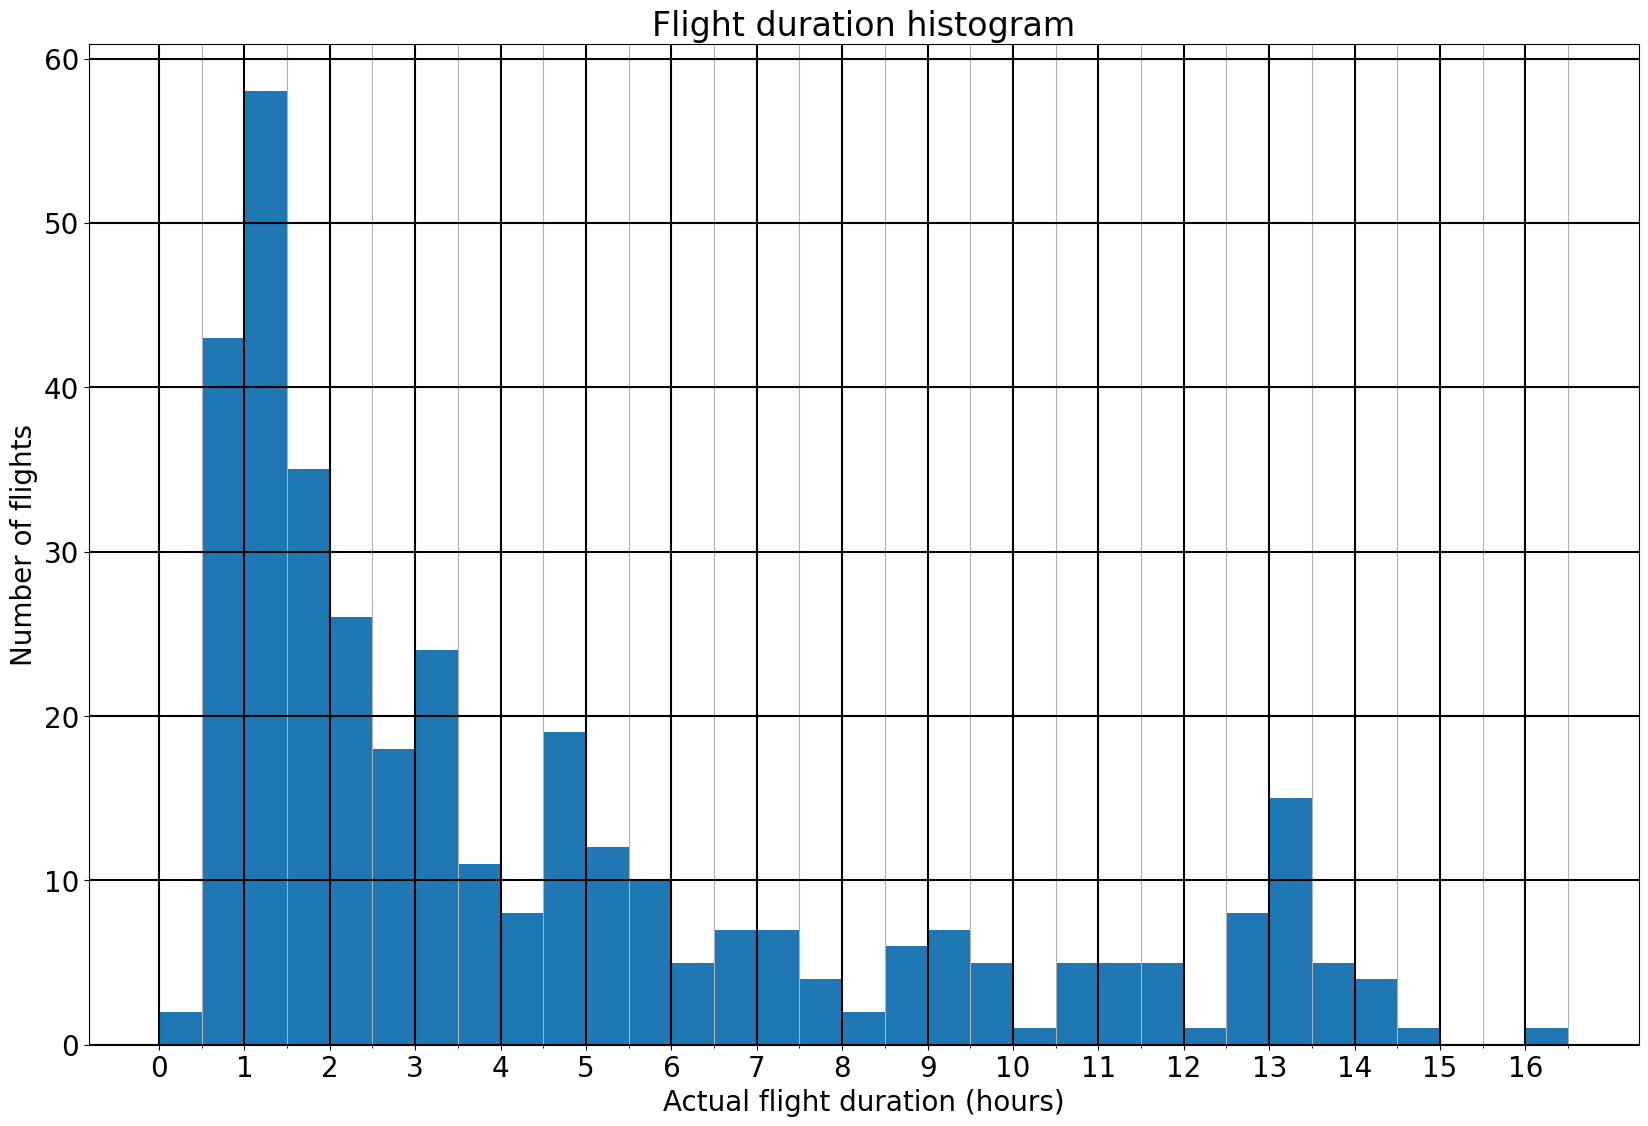

In [120]:
fig, ax = plt.subplots(1, 1, figsize=(20,13))
bins = list(range(0, math.ceil(df['Actual Duration (min)'].max()/30)*30+30, 30))
ax.hist(df['Actual Duration (min)'], bins=bins)
ax.set_xticks(bins, minor=True)
ax.set_xticks([b for i, b in enumerate(bins) if i%2 == 0])
ax.set_xticklabels([b//60 for i, b in enumerate(bins) if i%2 == 0])
ax.grid(which='major', linewidth=1.5, color='black')
ax.grid(which='minor', axis='both')
ax.set_xlabel('Actual flight duration (hours)')
ax.set_ylabel('Number of flights')
ax.set_title('Flight duration histogram')
plt.savefig(ROOT_DIR + 'figures/duration_hist.jpg', bbox_inches='tight')

df.sort_values(['Actual Duration (min)'], ascending=False).head(20)[important_cols]

# TOP AIRLINES

In [121]:
airlines = df.groupby('Airline').agg({'Flight': 'count', 'Actual Duration (min)': sum, 'Distance': sum})
airlines = airlines.sort_values(by='Flight', ascending=False)
airlines.head(20)

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1316924436.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  airlines = df.groupby('Airline').agg({'Flight': 'count', 'Actual Duration (min)': sum, 'Distance': sum})


,Flight,Actual Duration (min),Distance
Airline,,,
United,158,51023.0,429844
Air China,23,6092.0,46090
Hainan,14,6244.0,50973
China Southern,14,2053.0,15448
Ryanair,13,1940.0,12763
Lufthansa,10,3533.0,30640
JetBlue,9,1846.0,14963
TAP,8,2664.0,21505
Delta,8,608.0,4032


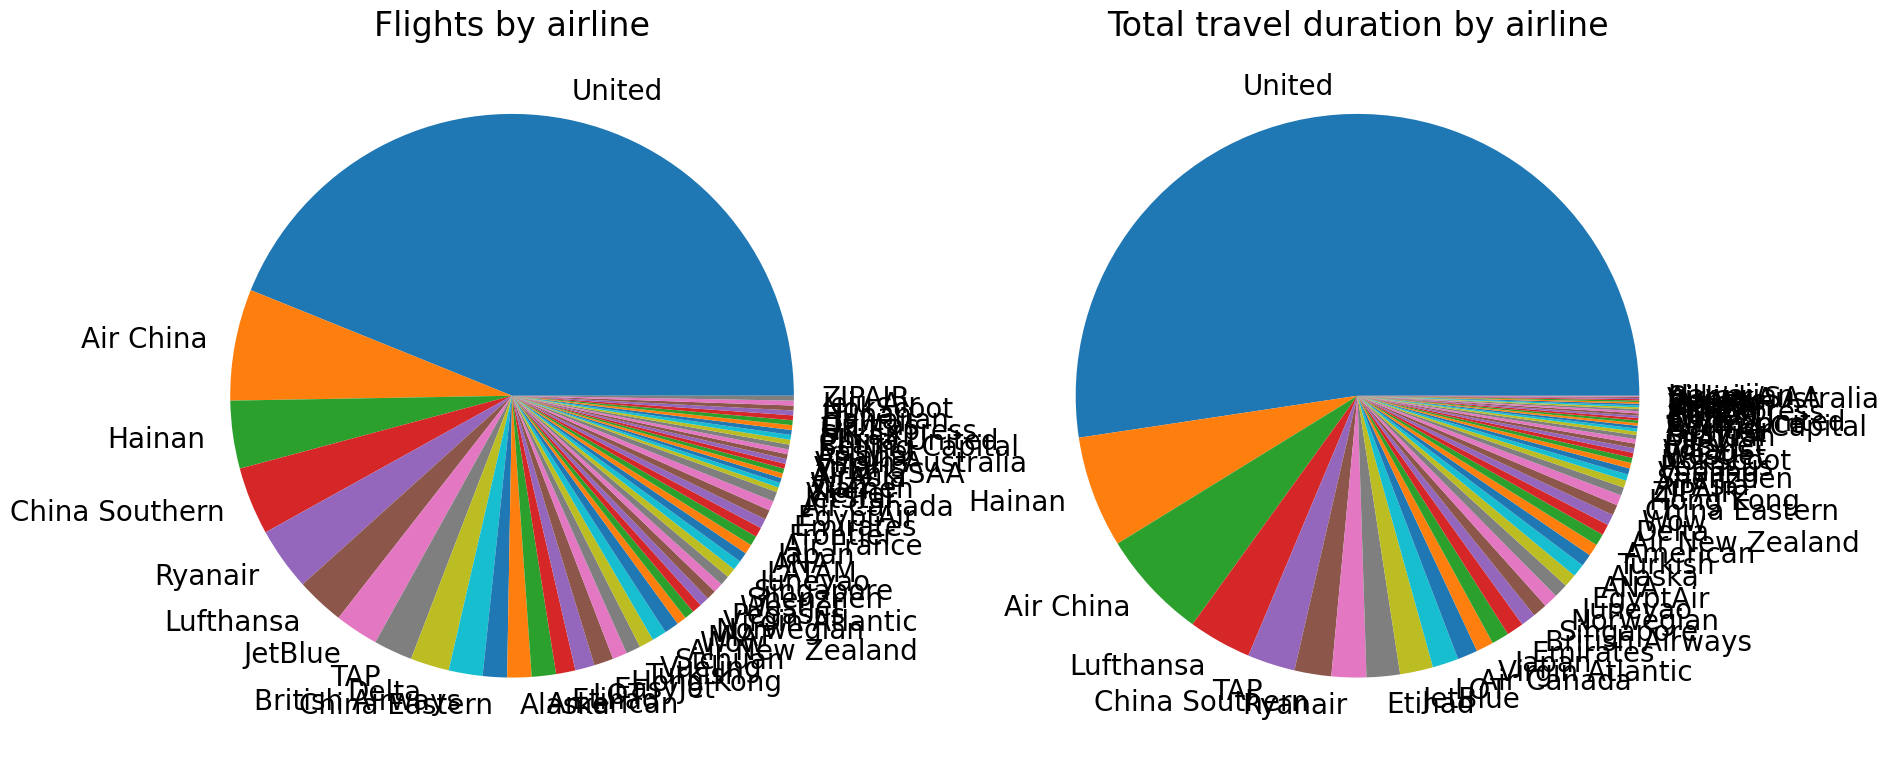

In [122]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))
airlines.plot('Airline', 'Flight', kind='pie', legend=False, ax=ax[0])
airlines.sort_values(by='Actual Duration (min)', ascending=False).plot('Airline', 'Actual Duration (min)', kind='pie', legend=False, ax=ax[1])
ax[0].set_title('Flights by airline')
ax[1].set_title('Total travel duration by airline')
ax[0].set_ylabel('')
ax[1].set_ylabel('')
plt.savefig(ROOT_DIR + 'figures/airlines.jpg', bbox_inches='tight')


# TOP AIRCRAFT

In [123]:
aircraft = df.groupby(['Aircraft']).agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
aircraft.columns = ['Count', 'Total Distance', 'Actual Duration (min)']
aircraft

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2950470887.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  aircraft = df.groupby(['Aircraft']).agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)


,Count,Total Distance,Actual Duration (min)
Aircraft,,,
B738,53,59596,8262.0
A320,40,29138,4198.0
B772,30,165145,18935.0
B789,26,120869,13910.0
A321,19,23695,3120.0
B739,18,14166,1998.0
A319,16,11775,1713.0
B77W,14,61236,7117.0
B752,13,34880,4220.0


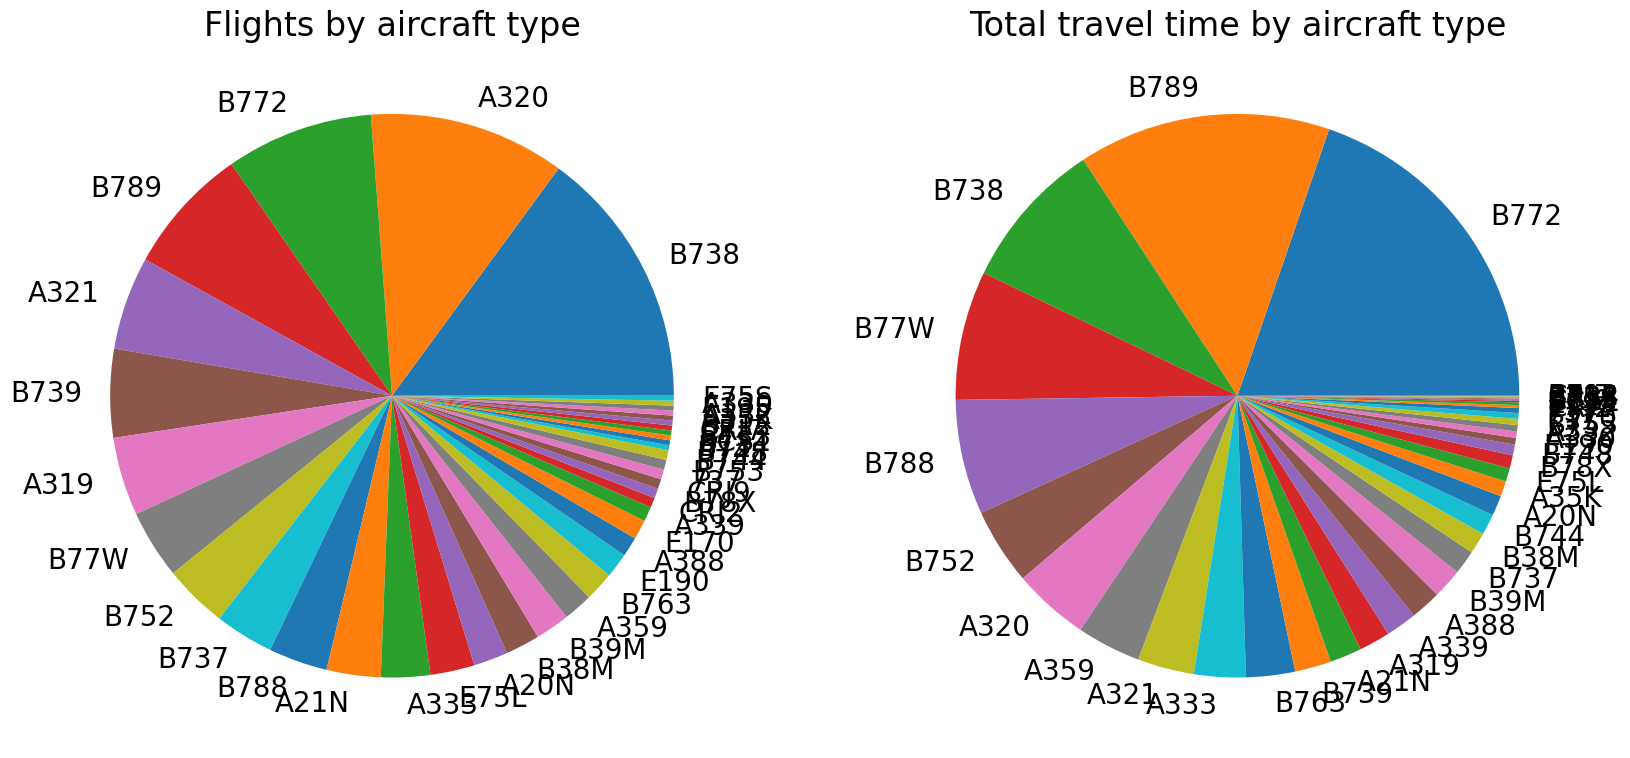

In [124]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))
aircraft.plot('Aircraft', 'Count', kind='pie', legend=False, ax=ax[0])
aircraft.sort_values(by='Actual Duration (min)', ascending=False).plot('Aircraft', 'Actual Duration (min)', kind='pie', legend=False, ax=ax[1])
ax[0].set_title('Flights by aircraft type')
ax[1].set_title('Total travel time by aircraft type')
ax[0].set_ylabel('')
ax[1].set_ylabel('')
plt.savefig(ROOT_DIR + 'figures/aircrafts.jpg', bbox_inches='tight')


# TOP AIRCRAFT REGS

In [125]:
reg = df.groupby(['Registration', 'Aircraft']).agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False).head(15)
reg.columns = ['Count', 'Total Distance']
reg

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3490438783.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  reg = df.groupby(['Registration', 'Aircraft']).agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False).head(15)


,,Count,Total Distance
Registration,Aircraft,,
N76010,B772,3,20178
N78005,B772,3,20493
N33284,B738,2,1955
N48127,B752,2,6048
N975JT,A321,2,3228
N37018,B772,2,12489
B207N,B789,2,6076
B7880,B789,2,1364
N33203,B738,2,1753


# TRAVEL BY YEAR

In [126]:
dist_year = df.groupby(df['Date'].dt.year).agg({'Distance': sum, 'Actual Duration (min)': sum, 'Date': 'count'})
dist_year.columns = ['Distance', 'Actual Duration (min)', 'Flights']
missing_years = set(range(dist_year.index.min(), dist_year.index.max())) - set(dist_year.index)
for yr in missing_years:
    dist_year = dist_year.append(pd.DataFrame({'Distance': 0, 'Actual Duration (min)': 0, 'Flights': 0}, index=[yr]))
dist_year

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2651100000.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dist_year = df.groupby(df['Date'].dt.year).agg({'Distance': sum, 'Actual Duration (min)': sum, 'Date': 'count'})


,Distance,Actual Duration (min),Flights
Date,,,
2015,36175,4426.0,11
2016,58573,7009.0,22
2017,78052,9500.0,39
2018,77926,9282.0,26
2019,84246,10087.0,32
2020,48041,6064.0,30
2021,58953,7404.0,33
2022,88374,10323.0,35
2023,84550,10962.0,44


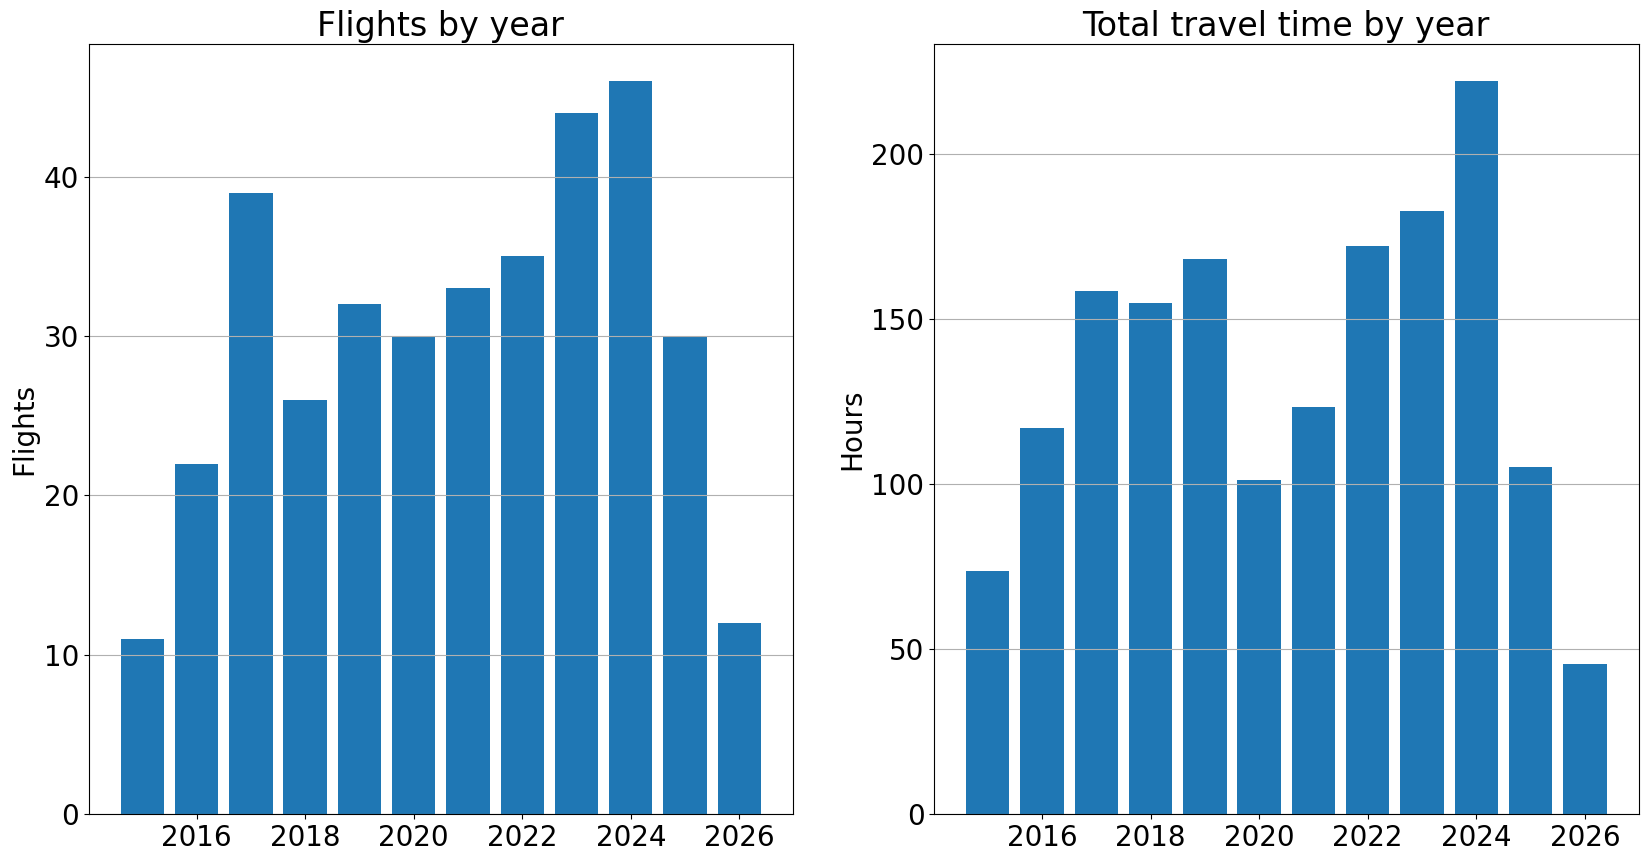

In [127]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))
ax[0].bar(dist_year.index, dist_year['Flights'])
ax[0].grid(axis='y')
ax[0].set_title('Flights by year')
ax[0].set_ylabel('Flights')
ax[1].bar(dist_year.index, dist_year['Actual Duration (min)']/60)
ax[1].grid(axis='y')
ax[1].set_title('Total travel time by year')
ax[1].set_ylabel('Hours')
plt.savefig(ROOT_DIR + 'figures/by_year.jpg', bbox_inches='tight')


# TRAVEL BY MONTH

In [128]:
df['Month'] = df['Date']
dist_yearm = df.groupby([df['Date'].dt.year, df['Month'].dt.month]).agg({'Distance': sum, 'Actual Duration (min)': sum, 'Date': 'count'})
dist_yearm.columns = ['Distance', 'Actual Duration (min)', 'Flights']

dist_yearm.sort_values(by='Distance', ascending=False).head(30)

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1669114295.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dist_yearm = df.groupby([df['Date'].dt.year, df['Month'].dt.month]).agg({'Distance': sum, 'Actual Duration (min)': sum, 'Date': 'count'})


Distance  Actual Duration (min)  Flights
Date Month                                          
2024 4         23585                 2730.0        8
2019 12        20872                 2402.0        7
2024 1         20637                 2830.0        8
2021 6         18559                 2312.0       10
2022 11        18244                 2032.0        4
2023 3         18179                 2233.0        7
     9         17879                 2069.0        4
2022 2         17772                 2054.0        6
2016 3         17482                 2157.0        8
2018 3         17029                 1969.0        3
2024 5         16902                 1854.0        4
2022 12        16797                 1912.0        6
2025 4         16470                 2137.0        8
2026 1         16015                 2125.0        8
2019 8         15448                 1750.0        3
2022 10        15008                 1770.0        6
2020 1         14596                 1781.0        8
2021 11        14546                 1795.0        6
2017 10        14366                 1696.0        4
2016 12        14233                 1762.0        6
2017 3         14064                 1610.0        4
2015 3         14064                 1673.0        4
2018 10        14064                 1668.0        4
2023 12        13636                 1983.0        7
2025 12        12983                 1550.0        5
2016 7         12787                 1462.0        5
2018 12        11673                 1550.0        3
     1         11150                 1152.0        2
2024 7         10367                 1261.0        6
2015 12        10152                 1320.0        4

In [129]:
import pandas as pd

def calculate_30_day_windows(df):
    # Ensure Date column is datetime and sort
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    windows = []
    unique_dates = df['Date'].unique()

    for start_date in unique_dates:
        end_date = start_date + pd.Timedelta(days=31)

        # Get flights in this 30-day window
        window_flights = df[(df['Date'] >= start_date) & (df['Date'] < end_date)]

        if len(window_flights) == 0:
            continue

        # Create flight signature for duplicate detection
        signature = tuple(sorted(zip(
            window_flights['Date'].dt.strftime('%Y-%m-%d'),
            window_flights['Flight'].astype(str),
            window_flights['Dep Airport'].astype(str),
            window_flights['Arr Airport'].astype(str)
        )))

        windows.append({
            'window_start': start_date,
            'window_end': end_date,
            'num_flights': len(window_flights),
            'total_distance': window_flights['Distance'].sum(),
            'total_duration_min': window_flights['Actual Duration (min)'].sum(),
            'flight_signature': signature
        })

    # Convert to DataFrame and remove duplicates and subsets
    windows_df = pd.DataFrame(windows)
    if not windows_df.empty:
        # First remove exact duplicates
        windows_df = windows_df.drop_duplicates(subset=['flight_signature'])

        # Remove windows that are strict subsets of other windows
        to_remove = []
        for i, row1 in windows_df.iterrows():
            sig1 = set(row1['flight_signature'])
            for j, row2 in windows_df.iterrows():
                if i != j and i not in to_remove:
                    sig2 = set(row2['flight_signature'])
                    # If sig1 is a strict subset of sig2, mark for removal
                    if sig1.issubset(sig2) and sig1 != sig2:
                        to_remove.append(i)
                        break

        # Remove subset windows
        windows_df = windows_df.drop(to_remove).drop('flight_signature', axis=1)
        windows_df = windows_df.sort_values('window_start').reset_index(drop=True)

    return windows_df

# Usage:
windows = calculate_30_day_windows(df)

# Sort by any metric you want:
# windows.sort_values('total_duration_min', ascending=False)  # Top by duration
# windows.sort_values('num_flights', ascending=False)         # Top by flight count
windows.sort_values('total_distance', ascending=False).head(20)      # Top by distance

,window_start,window_end,num_flights,total_distance,total_duration_min
107,2025-12-13,2026-01-13,12,28217,3552.0
65,2022-11-27,2022-12-28,8,25919,2879.0
93,2024-04-10,2024-05-11,7,24362,2738.0
7,2016-12-15,2017-01-15,8,24332,2829.0
92,2024-04-04,2024-05-05,9,24126,2753.0
91,2024-04-01,2024-05-02,8,23585,2730.0
36,2019-12-28,2020-01-28,10,22969,2736.0
106,2025-12-12,2026-01-12,11,22736,2786.0
62,2022-10-13,2022-11-13,5,22674,2605.0
31,2019-11-21,2019-12-22,9,21997,2622.0


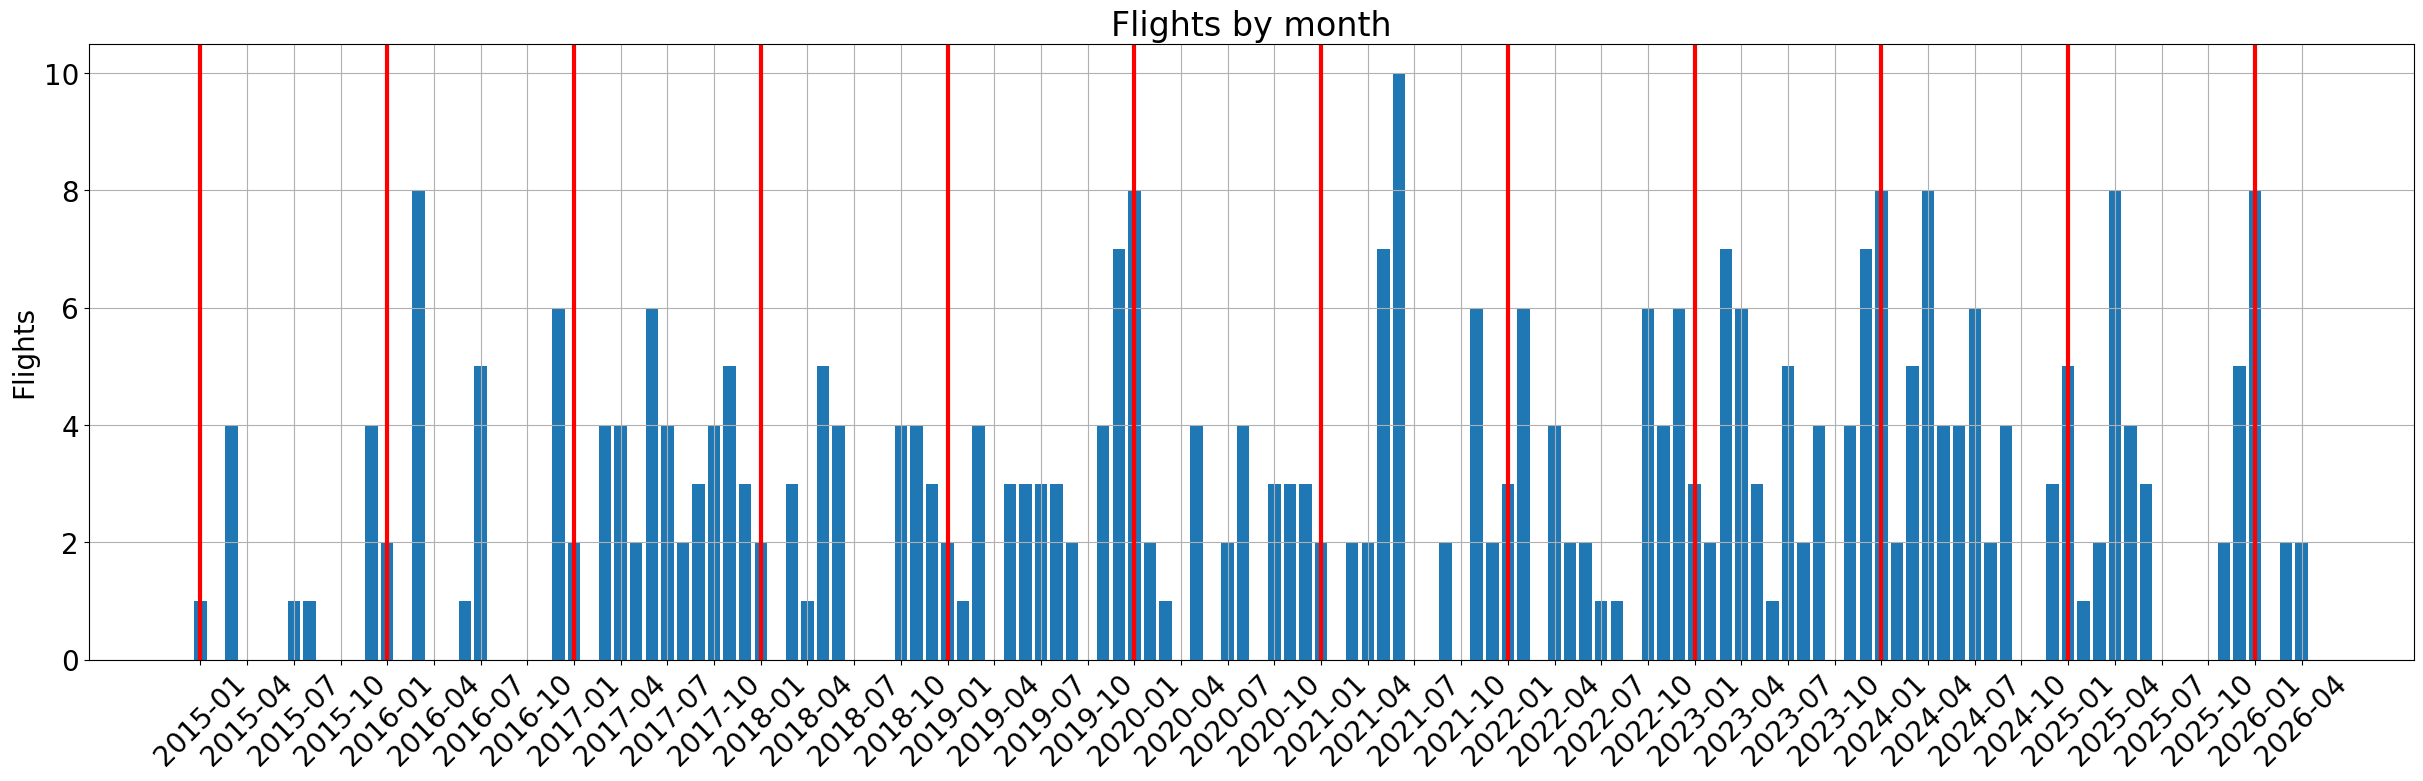

In [130]:
months = df['Month'].sort_values()
start_month = months.iloc[0]
end_month = months.iloc[-1]

index = pd.period_range(start_month, end_month, freq='M')
index_str = pd.DataFrame(index.astype(str), columns=['Y-M'])
# dist_yearm.reindex(index)

a = dist_yearm.reset_index()
a['Date'] = a['Date'].astype('int32').astype(str)
a['Month'] = a['Month'].astype('str').str.zfill(2)

a['Y-M'] = a['Date'] + '-' + a['Month']
a = a.merge(index_str, how='outer').sort_values(['Y-M']).fillna(0)

fig, ax = plt.subplots(figsize=(30,8))
ax.bar(a['Y-M'], a['Flights'], linewidth=5)
ticks = [x for i, x in enumerate(list(a['Y-M'])) if i % 3 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45)
ax.set_ylabel('Flights')
ax.set_title('Flights by month')
ax.grid(True)


for year in range(df['Date'].dt.year.min(), df['Date'].dt.year.max()+1): 
    if str(year) + '-01' in a['Y-M'].tolist():
        ax.axvline(str(year) + '-01', linewidth=3, color='red')
        
plt.savefig(ROOT_DIR + 'figures/flights_by_month.jpg', bbox_inches='tight')


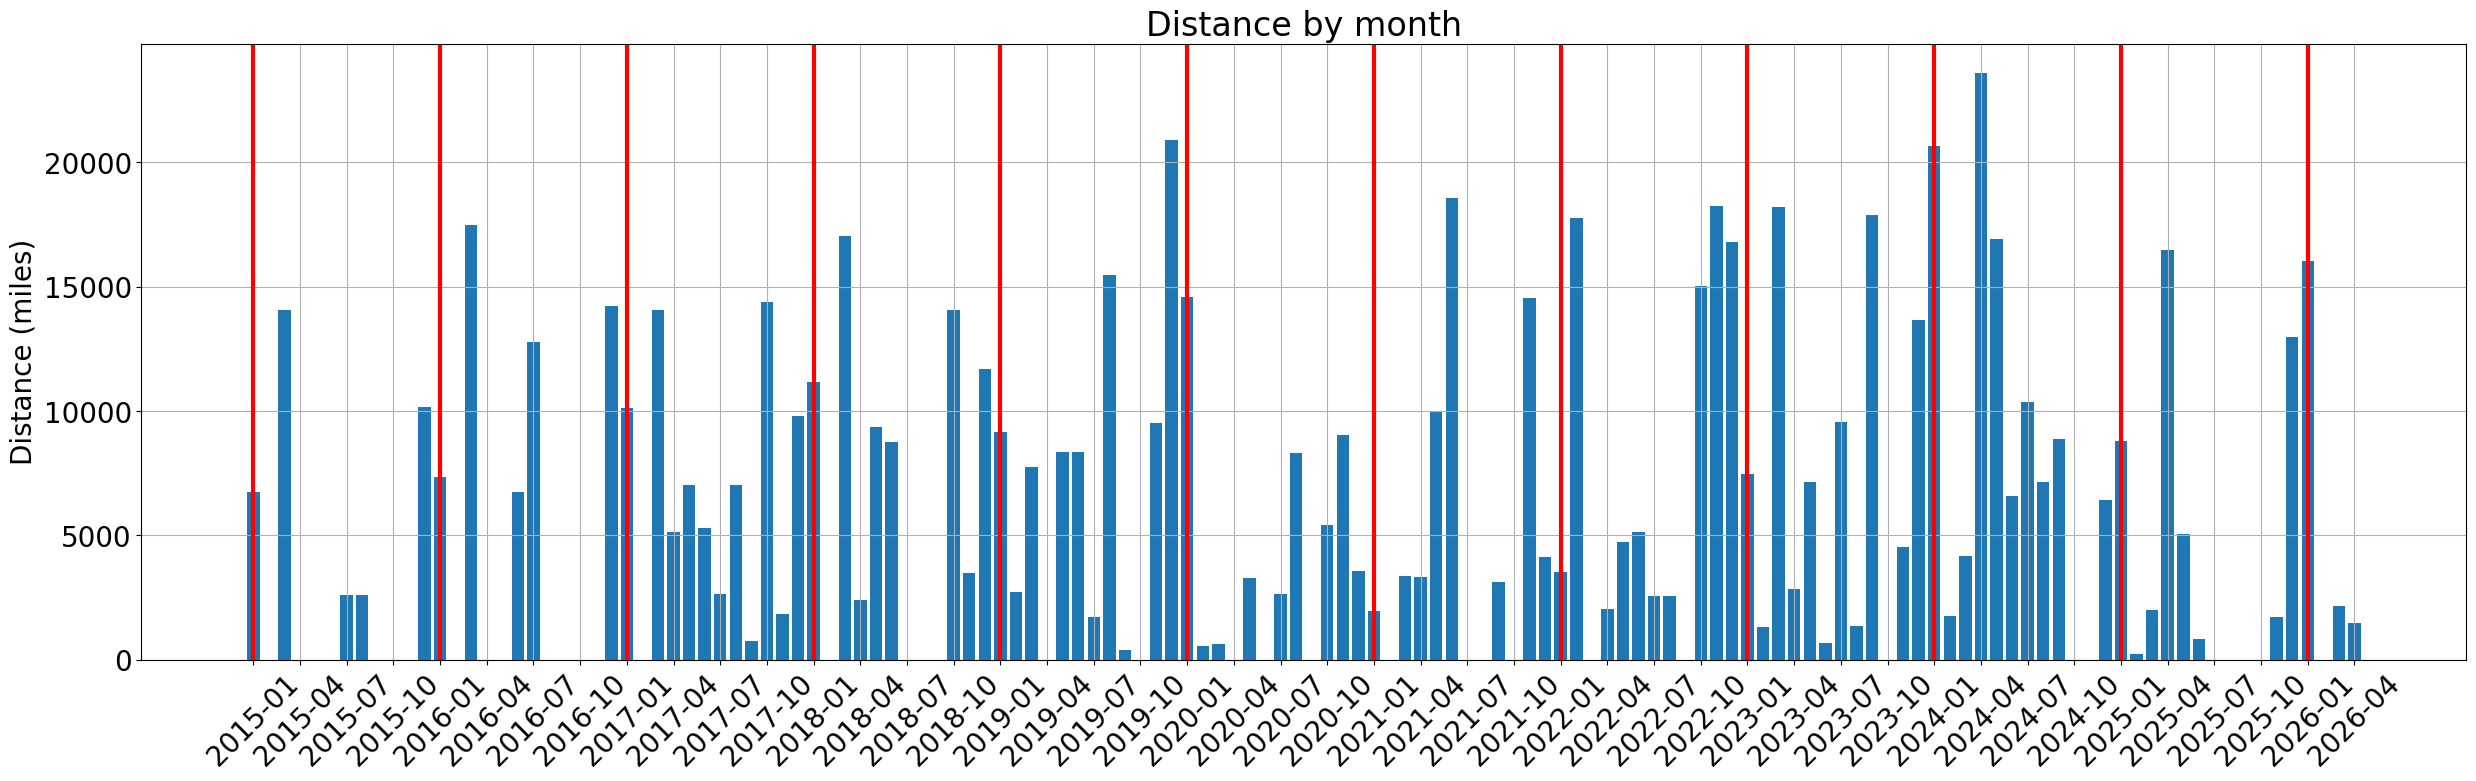

In [131]:
fig, ax = plt.subplots(figsize=(30,8))
ax.bar(a['Y-M'], a['Distance'], linewidth=5)
ticks = [x for i, x in enumerate(list(a['Y-M'])) if i % 3 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45)
ax.set_ylabel('Distance (miles)')
ax.set_title('Distance by month')
ax.grid(True)


for year in range(df['Date'].dt.year.min(), df['Date'].dt.year.max()+1): 
    if str(year) + '-01' in a['Y-M'].tolist():
        ax.axvline(str(year) + '-01', linewidth=3, color='red')
        
plt.savefig(ROOT_DIR + 'figures/distance_month.jpg', bbox_inches='tight')

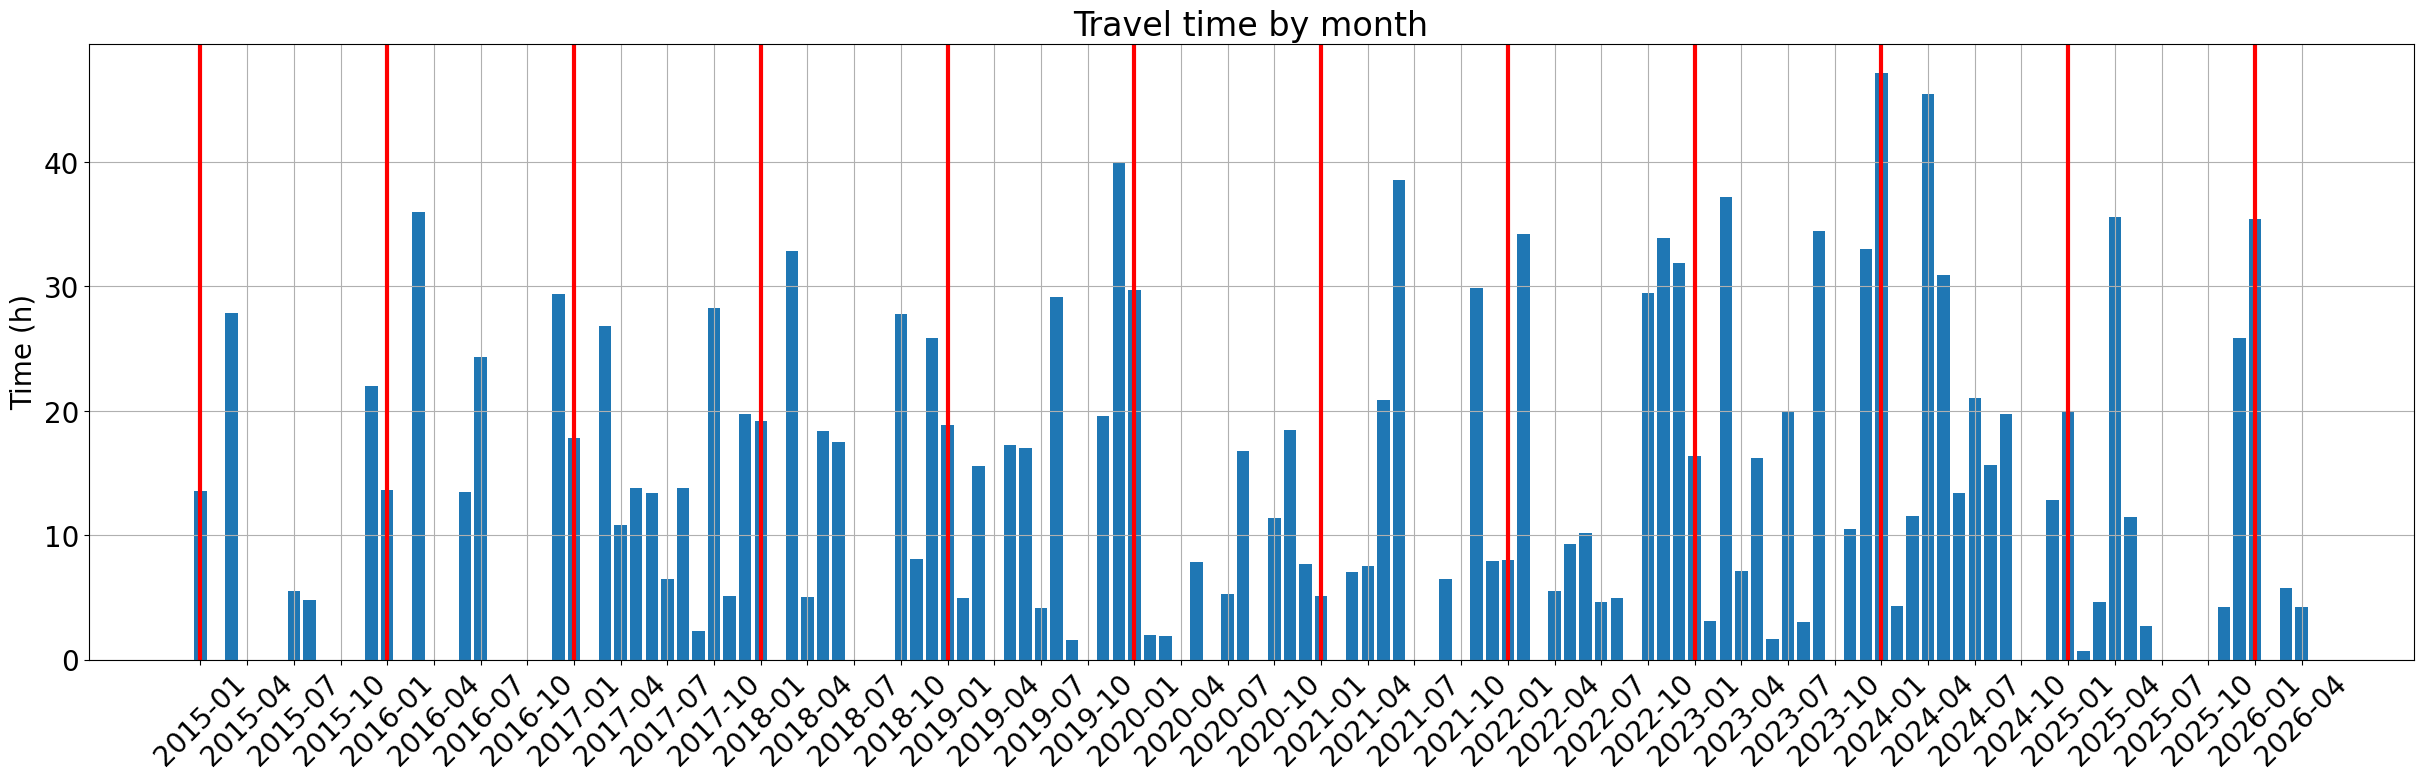

In [132]:
fig, ax = plt.subplots(figsize=(30,8))
ax.bar(a['Y-M'], a['Actual Duration (min)']/60, linewidth=5)
ticks = [x for i, x in enumerate(list(a['Y-M'])) if i % 3 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45)
ax.set_ylabel('Time (h)')
ax.set_title('Travel time by month')
ax.grid(True)


for year in range(df['Date'].dt.year.min(), df['Date'].dt.year.max()+1): 
    if str(year) + '-01' in a['Y-M'].tolist():
        ax.axvline(str(year) + '-01', linewidth=3, color='red')
        
plt.savefig(ROOT_DIR + 'figures/time_month.jpg', bbox_inches='tight')

# DOMESTIC AND INTERNATIONAL BREAKDOWN

In [133]:
dom_int = df.groupby('Domestic/International').agg({'Distance': sum, 'Date': 'count'})
dom_int.columns = ['Distance', 'Flights']
dom_int

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1625653085.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dom_int = df.groupby('Domestic/International').agg({'Distance': sum, 'Date': 'count'})


,Distance,Flights
Domestic/International,,
Domestic,199817,183
International,589148,177


In [134]:
print('Domestic average dist: ' + str(dom_int.loc['Domestic', 'Distance'] / dom_int.loc['Domestic', 'Flights']))
print('International average dist: ' + str(dom_int.loc['International', 'Distance'] / dom_int.loc['International', 'Flights']))

Domestic average dist: 1091.896174863388
International average dist: 3328.5197740112994


In [135]:
year_dom_int = df.groupby([df['Date'].dt.year, 'Domestic/International']).agg({'Distance': sum, 'Date': 'count'})
year_dom_int.columns = ['Distance', 'Flights']
year_dom_int = year_dom_int.reset_index()

# fig, ax = plt.subplots(figsize=(30,8))
# ax.bar(year_dom_int['Date'], year_dom_int['Date'], linewidth=5)
# # ticks = [x for i, x in enumerate(list(a['Y-M'])) if i % 3 == 0]
# # ax.set_xticks(ticks)
# # ax.set_xticklabels(ticks, rotation=45)
# # ax.set_ylabel('Flights')
# # ax.set_title('Flights by month')
# # ax.grid(True)

# plt.savefig('figures/domestic_international_year.jpg', bbox_inches='tight')

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/717766952.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  year_dom_int = df.groupby([df['Date'].dt.year, 'Domestic/International']).agg({'Distance': sum, 'Date': 'count'})


In [136]:
dom_int_country = df[df['Domestic/International'] == 'Domestic'].groupby('Dep Country').agg({'Distance': sum, 'Date': 'count'})
dom_int_country.columns = ['Distance', 'Flights']
dom_int_country.sort_values('Distance', ascending=False)

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/4001385294.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dom_int_country = df[df['Domestic/International'] == 'Domestic'].groupby('Dep Country').agg({'Distance': sum, 'Date': 'count'})


,Distance,Flights
Dep Country,,
United States,155566,126
China,38709,44
New Zealand,1100,2
Australia,906,2
France,864,2
Spain,837,2
Peru,728,2
Turkey,704,2
South Africa,403,1


# FARE CLASS BREAKDOWN

In [137]:
clas = df.groupby('Class').agg({'Distance': sum, 'Date': 'count'})
clas.columns = ['Distance', 'Flights']
clas

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/446002595.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  clas = df.groupby('Class').agg({'Distance': sum, 'Date': 'count'})


,Distance,Flights
Class,,
Economy,561546,285
International First,5699,1
Lie-flat Business,179184,37
Premium Economy,18826,6
Recliner First,23710,31


In [138]:
year_clas = df.groupby([df['Date'].dt.year, 'Class']).agg({'Distance': sum, 'Date': 'count'})
year_clas.columns = ['Distance', 'Flights']
year_clas

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3273458049.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  year_clas = df.groupby([df['Date'].dt.year, 'Class']).agg({'Distance': sum, 'Date': 'count'})


Distance  Flights
Date Class                                 
2015 Economy                 35773        9
     Recliner First            402        2
2016 Economy                 31518       16
     Lie-flat Business       26854        5
     Recliner First            201        1
2017 Economy                 51109       32
     Lie-flat Business       23930        4
     Recliner First           3013        3
2018 Economy                 59664       19
     Lie-flat Business       14788        3
     Recliner First           3474        4
2019 Economy                 45540       23
     Lie-flat Business       38092        7
     Recliner First            614        2
2020 Economy                 27504       19
     Lie-flat Business       15315        4
     Recliner First           5222        7
2021 Economy                 34462       24
     Lie-flat Business       19675        5
     Premium Economy          2419        1
     Recliner First           2397        3
2022 Economy                 58251       22
     International First      5699        1
     Lie-flat Business        9081        2
     Premium Economy          7529        3
     Recliner First           7814        7
2023 Economy                 67078       38
     Lie-flat Business        8021        2
     Premium Economy          8878        2
     Recliner First            573        2
2024 Economy                 94821       44
     Lie-flat Business       11593        2
2025 Economy                 42241       28
     Lie-flat Business        5789        2
2026 Economy                 13585       11
     Lie-flat Business        6046        1


# CLASS AND TRIP TYPE BREAKDOWN

In [139]:
clas_dom_int = df.groupby(['Domestic/International', 'Class']).agg({'Distance': sum, 'Date': 'count'})
clas_dom_int.columns = ['Distance', 'Flights']
clas_dom_int

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1814112429.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  clas_dom_int = df.groupby(['Domestic/International', 'Class']).agg({'Distance': sum, 'Date': 'count'})


Distance  Flights
Domestic/International Class                                 
Domestic               Economy                146134      144
                       Lie-flat Business       29152       10
                       Premium Economy          9948        4
                       Recliner First          14583       25
International          Economy                415412      141
                       International First      5699        1
                       Lie-flat Business      150032       27
                       Premium Economy          8878        2
                       Recliner First           9127        6

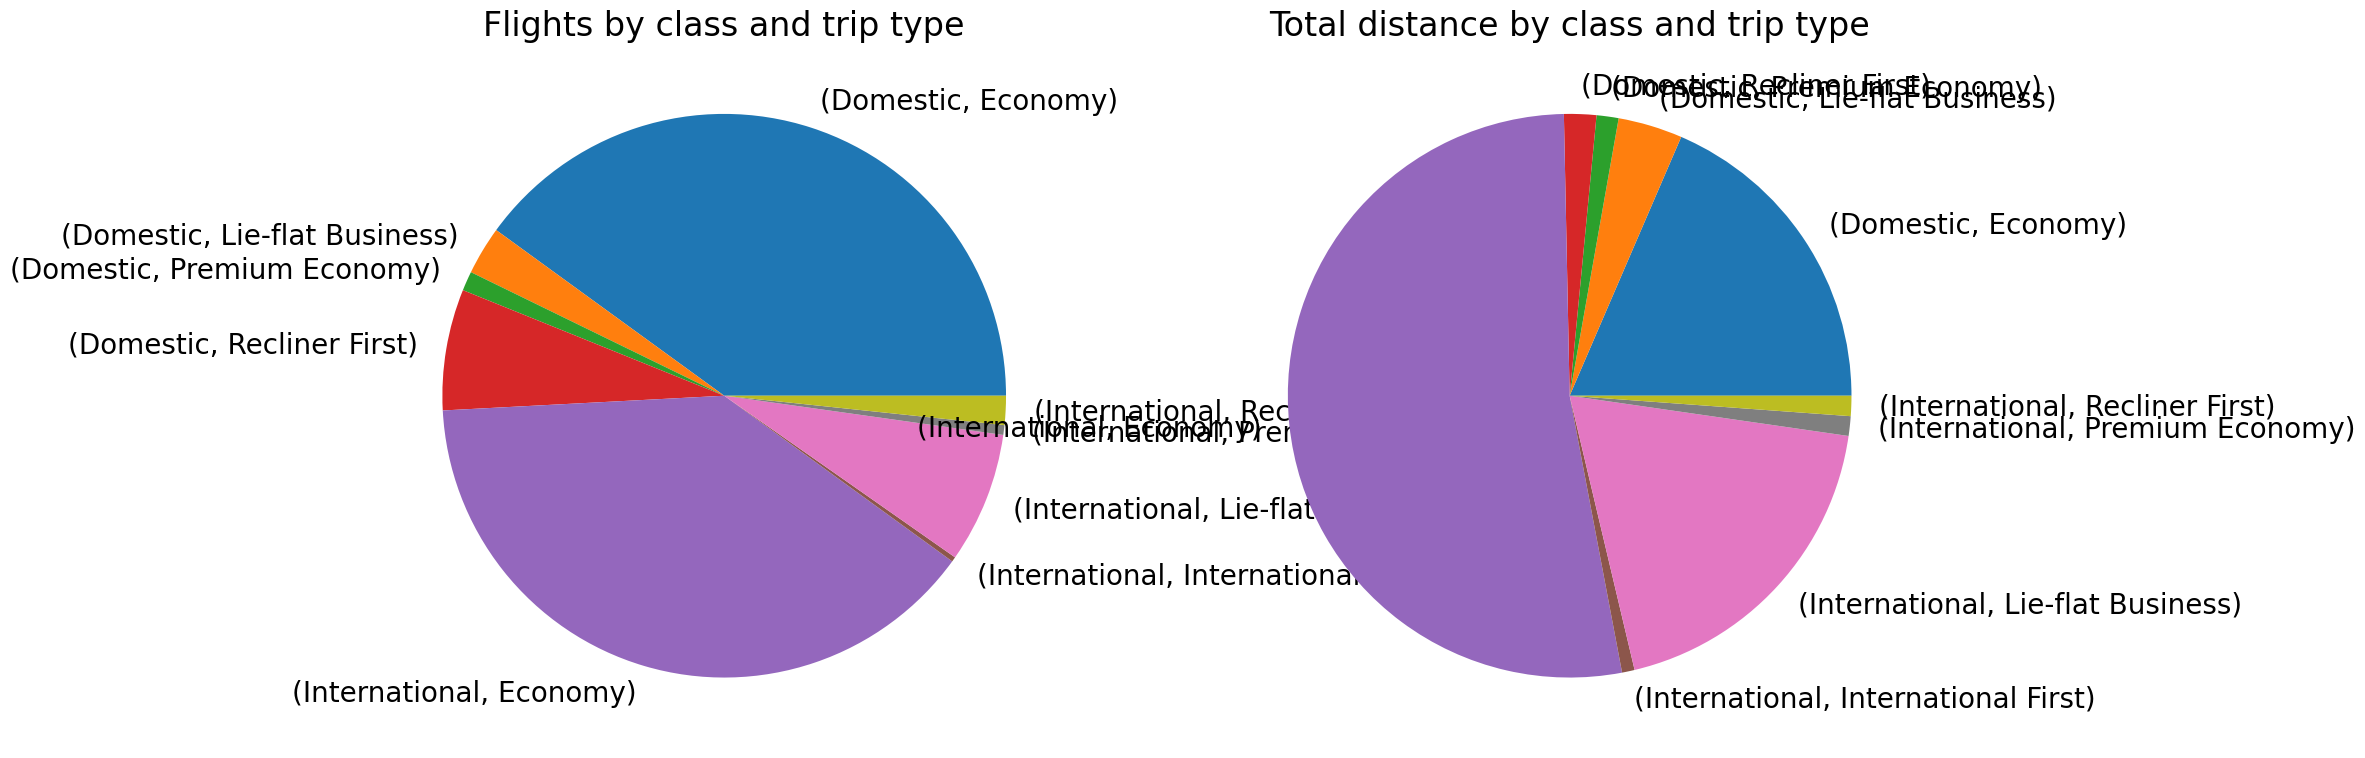

In [140]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))
clas_dom_int.plot('Class', 'Flights', kind='pie', legend=False, ax=ax[0])
clas_dom_int.plot('Class', 'Distance', kind='pie', legend=False, ax=ax[1])
ax[0].set_title('Flights by class and trip type')
ax[1].set_title('Total distance by class and trip type')
ax[0].set_ylabel('')
ax[1].set_ylabel('')
plt.savefig(ROOT_DIR + 'figures/class_and_type.jpg', bbox_inches='tight')

# DEP, ARR TIMES, DELAYS

Early arrivals: 238 67%
On time arrivals (within 15 min): 58 16%
Late arrivals: 48 13%
Really late arrivals (1+hour): 12 3%


,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Dep Time (Local),Actual Arr Time (Local),Actual Duration,Airline,Flight,Dep Airport,Arr Airport,Dep Delay,Arr Delay
0,2020-08-28 23:45:00,2020-08-29 06:51:00,2020-08-29 04:15:00,2020-08-29 10:43:00,0 days 04:28:00,United,UA1104,ANC,DEN,0 days 04:30:00,0 days 03:52:00
1,2018-06-02 21:05:00,2018-06-02 23:20:00,2018-06-03 01:02:00,2018-06-03 03:00:00,0 days 01:58:00,Hainan,HU7178,HGH,PEK,0 days 03:57:00,0 days 03:40:00
2,2022-08-04 20:30:00,2022-08-04 23:41:00,2022-08-05 00:33:00,2022-08-05 02:29:00,0 days 04:56:00,United,UA1257,EWR,SFO,0 days 04:03:00,0 days 02:48:00
3,2017-03-11 12:00:00,2017-03-12 15:00:00,2017-03-11 15:44:00,2017-03-12 17:28:00,0 days 12:44:00,United,UA89,EWR,PEK,0 days 03:44:00,0 days 02:28:00
4,2021-06-04 15:10:00,2021-06-04 16:21:00,2021-06-04 18:00:00,2021-06-04 18:47:00,0 days 00:47:00,United,UA3433,EWR,BOS,0 days 02:50:00,0 days 02:26:00
5,2025-01-07 17:00:00,2025-01-07 18:40:00,2025-01-07 18:58:00,2025-01-07 20:09:00,0 days 01:11:00,Vueling,VY2119,BCN,AGP,0 days 01:58:00,0 days 01:29:00
6,2020-02-19 06:46:00,2020-02-19 08:25:00,2020-02-19 08:35:00,2020-02-19 09:51:00,0 days 01:16:00,JetBlue,B6159,BOS,PHL,0 days 01:49:00,0 days 01:26:00
7,2024-09-09 12:10:00,2024-09-09 14:35:00,2024-09-09 13:41:00,2024-09-09 15:57:00,0 days 02:16:00,China United,KN5822,HJJ,PKX,0 days 01:31:00,0 days 01:22:00
8,2019-12-18 20:30:00,2019-12-19 18:00:00,2019-12-18 22:44:00,2019-12-19 19:17:00,0 days 13:33:00,United,UA1122,EWR,CPT,0 days 02:14:00,0 days 01:17:00
9,2024-07-11 18:05:00,2024-07-11 21:39:00,2024-07-11 19:44:00,2024-07-11 22:51:00,0 days 02:07:00,Westjet,WS1523,SFO,YYC,0 days 01:39:00,0 days 01:12:00


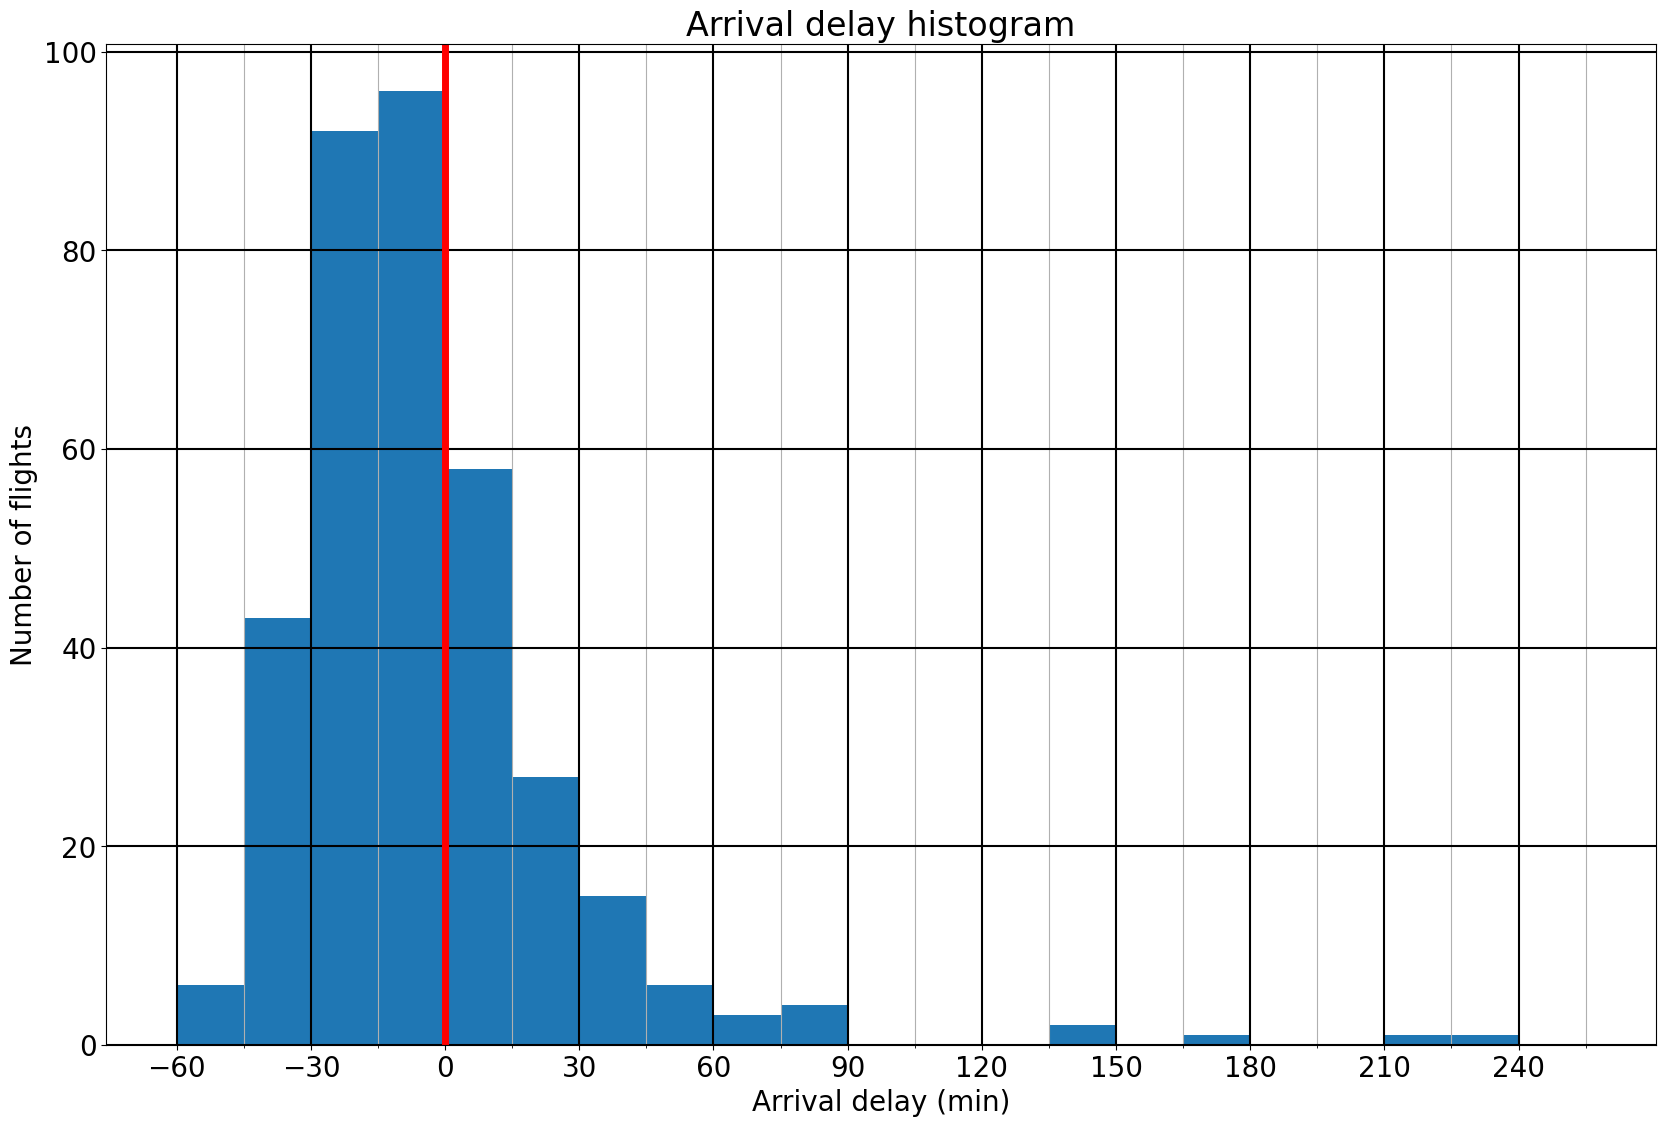

In [141]:
# ARRIVAL DEAYS
delay_cols = ['Scheduled Dep Time (Local)', 'Scheduled Arr Time (Local)', 'Actual Dep Time (Local)', 'Actual Arr Time (Local)', 'Actual Duration', 'Airline', 'Flight', 'Dep Airport', 'Arr Airport', 'Dep Delay', 'Arr Delay']

early_arrivals = past_df[past_df['Arr Delay (min)'] < 0].shape[0]
on_time_arrivals = past_df[(past_df['Arr Delay (min)'] >= 0) & (past_df['Arr Delay (min)'] < 15)].shape[0]
late_arrivals = past_df[(past_df['Arr Delay (min)'] >= 15) & (past_df['Arr Delay (min)'] < 60)].shape[0]
really_late_arrivals = past_df[past_df['Arr Delay (min)'] >= 60].shape[0]

print('Early arrivals:', early_arrivals, str(round(100*early_arrivals/NUM_FLIGHTS_PAST))+'%')
print('On time arrivals (within 15 min):', on_time_arrivals, str(round(100*on_time_arrivals/NUM_FLIGHTS_PAST))+'%')
print('Late arrivals:', late_arrivals, str(round(100*late_arrivals/NUM_FLIGHTS_PAST))+'%')
print('Really late arrivals (1+hour):', really_late_arrivals, str(round(100*really_late_arrivals/NUM_FLIGHTS_PAST))+'%')

bins = list(range(-60, math.ceil(past_df['Arr Delay (min)'].max()/30)*30+30, 15))
fig, ax = plt.subplots(figsize=(20,13))
ax.hist(past_df['Arr Delay (min)'], bins=bins)
ax.set_xticks(bins, minor=True)
ax.set_xticks([b for i, b in enumerate(bins) if b%2 == 0])
ax.grid(which='major', linewidth=1.5, color='black')
ax.grid(which='minor', axis='both')
ax.set_xlabel('Arrival delay (min)')
ax.set_ylabel('Number of flights')
ax.set_title('Arrival delay histogram')
ax.axvline(0, linewidth=5, color='red')
plt.savefig(ROOT_DIR + 'figures/arrival_delay.jpg', bbox_inches='tight')


past_df.sort_values('Arr Delay (min)', ascending=False).head(10).reset_index()[delay_cols]


Early departures: 5 1%
On time departures (within 15 min): 123 35%
Late departures: 203 57%
Really late departures (1+hour): 25 7%


,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Dep Time (Local),Actual Arr Time (Local),Actual Duration,Airline,Flight,Dep Airport,Arr Airport,Dep Delay,Arr Delay
0,2020-08-28 23:45:00,2020-08-29 06:51:00,2020-08-29 04:15:00,2020-08-29 10:43:00,0 days 04:28:00,United,UA1104,ANC,DEN,0 days 04:30:00,0 days 03:52:00
1,2022-08-04 20:30:00,2022-08-04 23:41:00,2022-08-05 00:33:00,2022-08-05 02:29:00,0 days 04:56:00,United,UA1257,EWR,SFO,0 days 04:03:00,0 days 02:48:00
2,2018-06-02 21:05:00,2018-06-02 23:20:00,2018-06-03 01:02:00,2018-06-03 03:00:00,0 days 01:58:00,Hainan,HU7178,HGH,PEK,0 days 03:57:00,0 days 03:40:00
3,2017-03-11 12:00:00,2017-03-12 15:00:00,2017-03-11 15:44:00,2017-03-12 17:28:00,0 days 12:44:00,United,UA89,EWR,PEK,0 days 03:44:00,0 days 02:28:00
4,2021-06-04 15:10:00,2021-06-04 16:21:00,2021-06-04 18:00:00,2021-06-04 18:47:00,0 days 00:47:00,United,UA3433,EWR,BOS,0 days 02:50:00,0 days 02:26:00
5,2022-12-11 09:20:00,2022-12-12 17:30:00,2022-12-11 11:46:00,2022-12-12 18:28:00,0 days 07:42:00,Air New Zealand,NZ9,HNL,AKL,0 days 02:26:00,0 days 00:58:00
6,2019-12-18 20:30:00,2019-12-19 18:00:00,2019-12-18 22:44:00,2019-12-19 19:17:00,0 days 13:33:00,United,UA1122,EWR,CPT,0 days 02:14:00,0 days 01:17:00
7,2018-04-02 15:30:00,2018-04-02 17:35:00,2018-04-02 17:31:00,2018-04-02 18:35:00,0 days 05:04:00,Wow,WW125,KEF,BOS,0 days 02:01:00,0 days 01:00:00
8,2025-01-07 17:00:00,2025-01-07 18:40:00,2025-01-07 18:58:00,2025-01-07 20:09:00,0 days 01:11:00,Vueling,VY2119,BCN,AGP,0 days 01:58:00,0 days 01:29:00
9,2020-02-19 06:46:00,2020-02-19 08:25:00,2020-02-19 08:35:00,2020-02-19 09:51:00,0 days 01:16:00,JetBlue,B6159,BOS,PHL,0 days 01:49:00,0 days 01:26:00


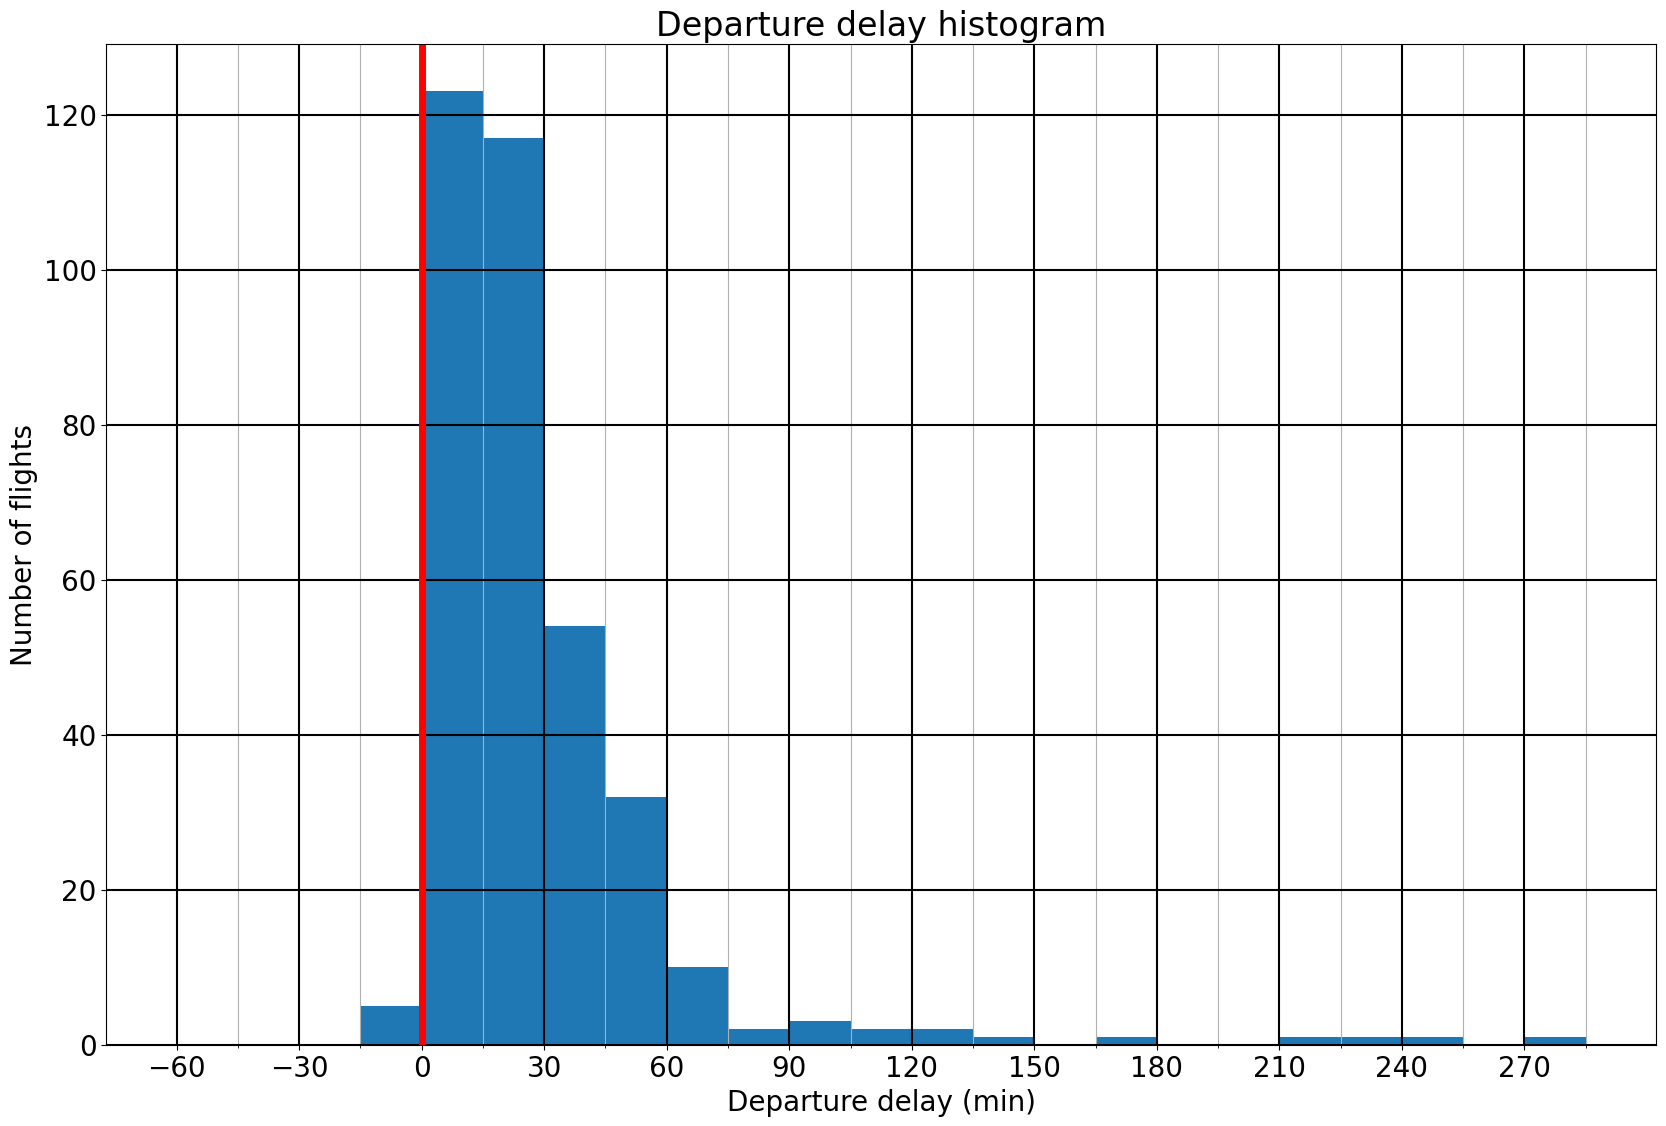

In [142]:
# DEPARTURE DELAYS

early_departures = past_df[past_df['Dep Delay (min)'] < 0].shape[0]
on_time_departures = past_df[(past_df['Dep Delay (min)'] >= 0) & (past_df['Dep Delay (min)'] < 15)].shape[0]
late_departures = past_df[(past_df['Dep Delay (min)'] >= 15) & (past_df['Dep Delay (min)'] < 60)].shape[0]
really_late_departures = past_df[past_df['Dep Delay (min)'] >= 60].shape[0]


print('Early departures:', early_departures, str(round(100*early_departures/NUM_FLIGHTS_PAST))+'%')
print('On time departures (within 15 min):', on_time_departures, str(round(100*on_time_departures/NUM_FLIGHTS_PAST))+'%')
print('Late departures:', late_departures, str(round(100*late_departures/NUM_FLIGHTS_PAST))+'%')
print('Really late departures (1+hour):', really_late_departures, str(round(100*really_late_departures/NUM_FLIGHTS_PAST))+'%')

bins = list(range(-60, math.ceil(past_df['Dep Delay (min)'].max()/30)*30+30, 15))
fig, ax = plt.subplots(figsize=(20,13))
ax.hist(past_df['Dep Delay (min)'], bins=bins)
ax.set_xticks(bins, minor=True)
ax.set_xticks([b for i, b in enumerate(bins) if b%2 == 0])
ax.grid(which='major', linewidth=1.5, color='black')
ax.grid(which='minor', axis='both')
ax.set_xlabel('Departure delay (min)')
ax.set_ylabel('Number of flights')
ax.set_title('Departure delay histogram')
ax.axvline(0, linewidth=5, color='red')
plt.savefig(ROOT_DIR + 'figures/departure_delay.jpg', bbox_inches='tight')

past_df.sort_values('Dep Delay (min)', ascending=False).head(10).reset_index()[delay_cols]


In [143]:
# Earliest arriving flights
delay_cols = ['Scheduled Dep Time (Local)', 'Scheduled Arr Time (Local)', 'Actual Dep Time (Local)', 'Actual Arr Time (Local)', 'Actual Duration', 'Airline', 'Flight', 'Dep Airport', 'Arr Airport', 'Dep Delay (min)', 'Arr Delay (min)']
past_df.sort_values('Arr Delay (min)', ascending=True).head(10).reset_index()[delay_cols]


,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Dep Time (Local),Actual Arr Time (Local),Actual Duration,Airline,Flight,Dep Airport,Arr Airport,Dep Delay (min),Arr Delay (min)
0,2024-05-03 17:00:00,2024-05-03 10:35:00,2024-05-03 17:10:00,2024-05-03 09:32:00,0 days 08:22:00,ANA,NH8,NRT,SFO,10.0,-63.0
1,2017-06-28 12:30:00,2017-06-28 13:35:00,2017-06-28 12:30:00,2017-06-28 12:40:00,0 days 01:10:00,China Southern,CZ318,GMP,PEK,0.0,-55.0
2,2017-12-20 12:00:00,2017-12-21 15:00:00,2017-12-20 12:15:00,2017-12-21 14:09:00,0 days 12:54:00,United,UA89,EWR,PEK,15.0,-51.0
3,2021-11-27 09:55:00,2021-11-27 14:55:00,2021-11-27 10:34:00,2021-11-27 14:05:00,0 days 11:31:00,TAP,TP237,LIS,SFO,39.0,-50.0
4,2023-07-11 16:50:00,2023-07-11 11:15:00,2023-07-11 17:00:00,2023-07-11 10:26:00,0 days 09:26:00,United,UA34,KIX,SFO,10.0,-49.0
5,2020-01-19 16:55:00,2020-01-19 19:10:00,2020-01-19 16:55:00,2020-01-19 18:23:00,0 days 01:28:00,Air China,CA1611,PEK,HRB,0.0,-47.0
6,2023-01-20 08:35:00,2023-01-20 12:02:00,2023-01-20 08:41:00,2023-01-20 11:15:00,0 days 05:34:00,United,UA731,PHL,SFO,6.0,-47.0
7,2025-12-17 20:45:00,2025-12-17 23:10:00,2025-12-17 20:49:00,2025-12-17 22:25:00,0 days 01:36:00,China Southern,CZ8853,PKX,HGH,4.0,-45.0
8,2018-11-23 10:09:00,2018-11-23 14:45:00,2018-11-23 10:19:00,2018-11-23 14:00:00,0 days 02:41:00,United,UA5481,ORD,NAS,10.0,-45.0
9,2025-04-23 23:20:00,2025-04-24 08:12:00,2025-04-23 23:30:00,2025-04-24 07:28:00,0 days 04:58:00,United,UA1665,SFO,BOS,10.0,-44.0


In [144]:
# Earliest departing flights
past_df.sort_values('Dep Delay (min)', ascending=True).head(10).reset_index()[delay_cols]




,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Dep Time (Local),Actual Arr Time (Local),Actual Duration,Airline,Flight,Dep Airport,Arr Airport,Dep Delay (min),Arr Delay (min)
0,2024-03-10 17:40:00,2024-03-10 19:00:00,2024-03-10 17:26:00,2024-03-10 18:34:00,0 days 01:08:00,China Southern,CZ6614,KJI,URC,-14.0,-26.0
1,2020-03-15 12:47:00,2020-03-15 15:00:00,2020-03-15 12:39:00,2020-03-15 14:31:00,0 days 01:52:00,Delta,DL2667,BOS,DTW,-8.0,-29.0
2,2023-12-16 19:55:00,2023-12-16 21:00:00,2023-12-16 19:48:00,2023-12-16 20:43:00,0 days 00:55:00,LOT,LO526,PRG,WAW,-7.0,-17.0
3,2019-11-28 08:20:00,2019-11-28 20:50:00,2019-11-28 08:14:00,2019-11-28 20:40:00,0 days 07:26:00,United,UA122,IAD,LHR,-6.0,-10.0
4,2024-03-10 20:30:00,2024-03-11 00:15:00,2024-03-10 20:29:00,2024-03-10 23:54:00,0 days 01:25:00,China Southern,CZ6909,URC,PKX,-1.0,-21.0
5,2016-03-24 20:50:00,2016-03-24 22:50:00,2016-03-24 20:50:00,2016-03-24 22:15:00,0 days 01:25:00,China Eastern,MU2117,XIY,PEK,0.0,-35.0
6,2019-05-30 07:55:00,2019-05-30 11:40:00,2019-05-30 07:55:00,2019-05-30 11:16:00,0 days 03:21:00,Air China,CA1469,PEK,LJG,0.0,-24.0
7,2020-01-19 16:55:00,2020-01-19 19:10:00,2020-01-19 16:55:00,2020-01-19 18:23:00,0 days 01:28:00,Air China,CA1611,PEK,HRB,0.0,-47.0
8,2016-03-16 09:35:00,2016-03-16 12:40:00,2016-03-16 09:35:00,2016-03-16 12:20:00,0 days 02:45:00,Hainan,HU7215,PEK,KWL,0.0,-20.0
9,2021-04-29 15:30:00,2021-04-29 19:50:00,2021-04-29 15:30:00,2021-04-29 19:36:00,0 days 04:06:00,United,UA1784,STT,EWR,0.0,-14.0


In [145]:
# Arrival delay by year
delay_by_year = past_df.groupby(past_df['Date'].dt.year)['Arr Delay (min)'].aggregate(
    count='count', 
    early_flights=lambda x: x[x<=0].count(),
    late_flights=lambda x: x[x>0].count(),
    percent_early=lambda x: 100*(x[x<=0].count()/len(x)),
    avg_gained_time=lambda x: x[x <= 0].mean(), 
    avg_lost_time=lambda x: x[x > 0].mean(), 
    avg_net_time_lost='mean',
    total_net_time_lost=sum).fillna(0).round().astype(int, errors='ignore')

delay_by_year

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3840423199.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  delay_by_year = past_df.groupby(past_df['Date'].dt.year)['Arr Delay (min)'].aggregate(


,count,early_flights,late_flights,percent_early,avg_gained_time,avg_lost_time,avg_net_time_lost,total_net_time_lost
Date,,,,,,,,
2015,11,5,6,45,-18,22,4,40
2016,22,16,6,73,-21,5,-14,-308
2017,39,28,11,72,-24,36,-7,-284
2018,26,19,7,73,-19,59,2,55
2019,32,24,8,75,-16,27,-6,-178
2020,30,22,8,73,-24,47,-5,-159
2021,33,24,9,73,-17,29,-5,-157
2022,35,24,11,69,-18,37,-1,-34
2023,44,35,9,80,-21,20,-13,-566


In [146]:
# Arrival delay by airline
top_airlines = past_df.groupby('Airline').agg({'Date': 'count'})
top_airlines = top_airlines[top_airlines['Date'] >= 8].index.tolist()
filtered_rows = past_df[past_df['Airline'].isin(top_airlines)]
arrival_delay_by_airline = filtered_rows.groupby(filtered_rows['Airline'])['Arr Delay (min)'].aggregate(
    count='count', 
    early_flights=lambda x: x[x<=0].count(),
    late_flights=lambda x: x[x>0].count(),
    percent_early=lambda x: 100*(x[x<=0].count()/len(x)),
    avg_gained_time=lambda x: x[x <= 0].mean(), 
    avg_lost_time=lambda x: x[x > 0].mean(), 
    avg_net_time_lost='mean').sort_values('percent_early', ascending=False)

delay_by_airline = arrival_delay_by_airline.fillna(0).round().astype(int, errors='ignore')

delay_by_airline

,count,early_flights,late_flights,percent_early,avg_gained_time,avg_lost_time,avg_net_time_lost
Airline,,,,,,,
Delta,8,8,0,100,-24,0,-24
United,158,124,34,78,-22,34,-10
JetBlue,9,7,2,78,-16,44,-3
Air China,23,16,7,70,-17,18,-6
China Southern,14,9,5,64,-22,27,-4
Lufthansa,10,6,4,60,-14,18,-1
Hainan,14,8,6,57,-24,66,14
TAP,8,4,4,50,-19,20,0
Ryanair,10,3,7,30,-10,15,8


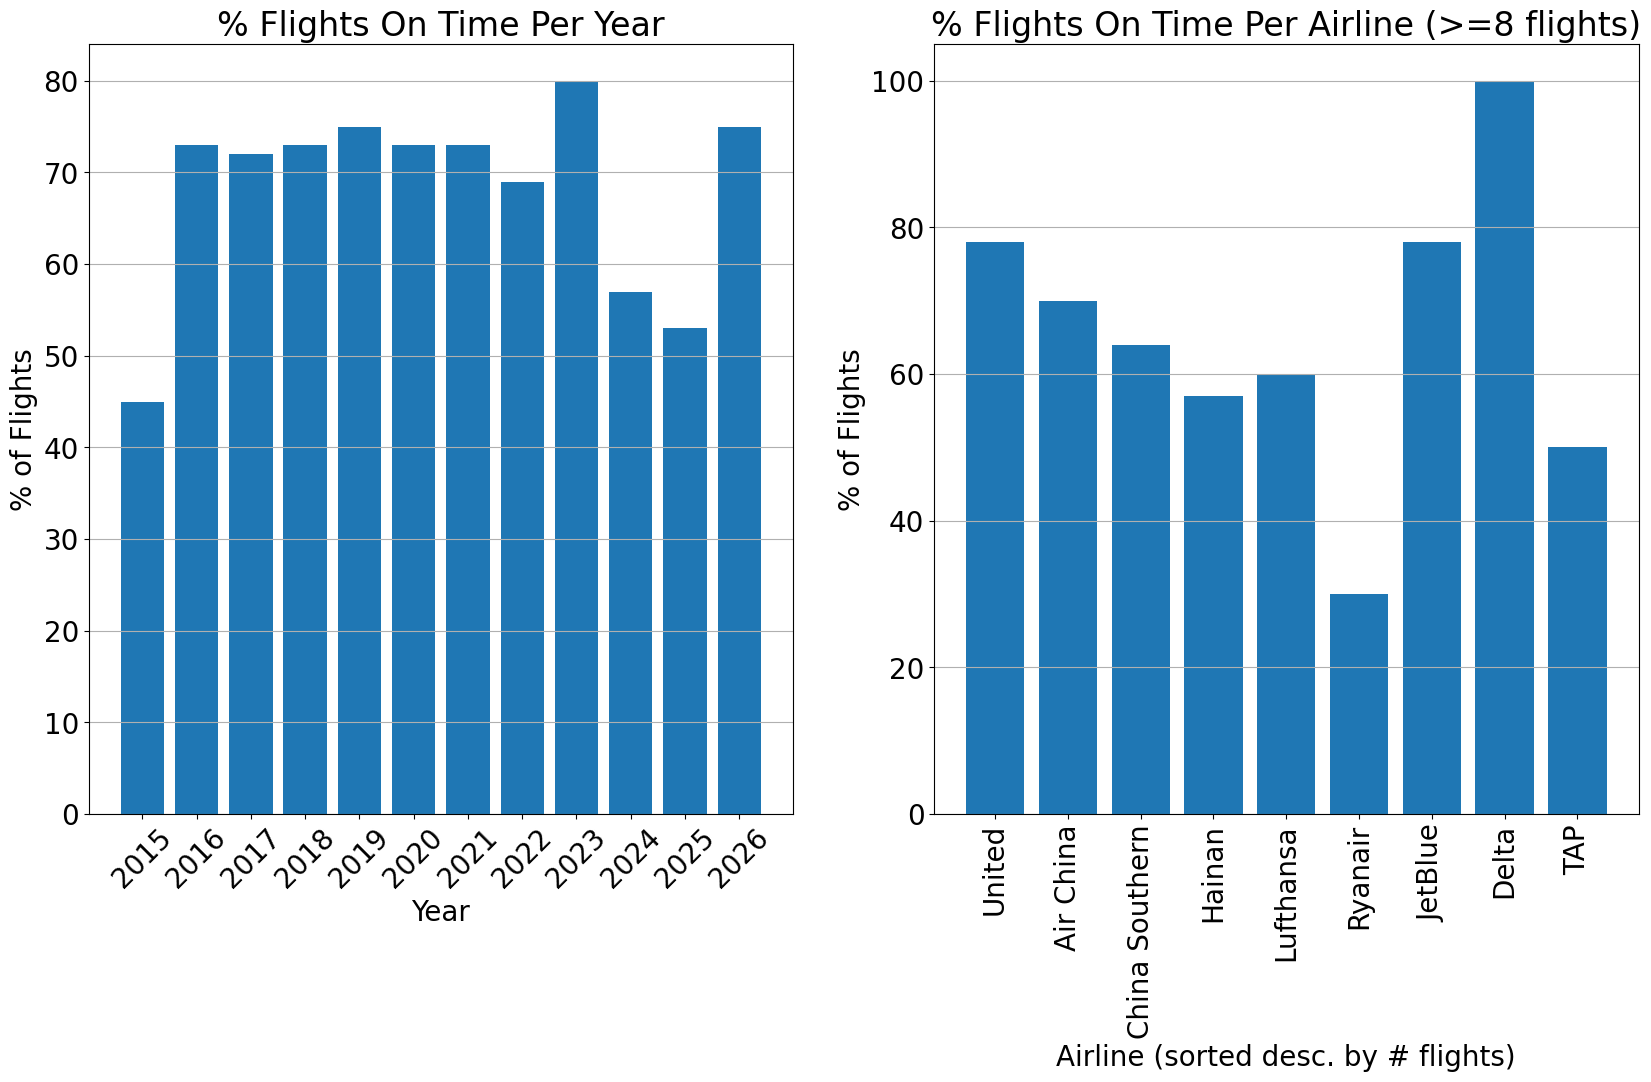

In [147]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))
ax[0].bar(delay_by_year.index, delay_by_year['percent_early'])
ax[0].grid(axis='y')
ax[0].set_title('% Flights On Time Per Year')
ax[0].set_ylabel('% of Flights')
ax[0].set_xticks(delay_by_year.index)
ax[0].set_xlabel('Year')
ax[0].tick_params(axis='x', rotation=45)
ax[1].bar(delay_by_airline.sort_values(by='count', ascending=False).index, delay_by_airline.sort_values(by='count', ascending=False)['percent_early'])
ax[1].grid(axis='y')
ax[1].set_title('% Flights On Time Per Airline (>=8 flights)')
ax[1].set_ylabel('% of Flights')
ax[1].set_xlabel('Airline (sorted desc. by # flights)')
ax[1].tick_params(axis='x', rotation=90)
plt.savefig(ROOT_DIR + 'figures/delays_bar.jpg', bbox_inches='tight')

,Scheduled Dep Time (Local),Scheduled Arr Time (Local),Actual Dep Time (Local),Actual Arr Time (Local),Scheduled Duration,Actual Duration,Airline,Flight,Dep Airport,Arr Airport,Dep Delay (min),Arr Delay (min),Minutes Made Up
190,2021-11-27 09:55:00,2021-11-27 14:55:00,2021-11-27 10:34:00,2021-11-27 14:05:00,0 days 13:00:00,0 days 11:31:00,TAP,TP237,LIS,SFO,39.0,-50.0,89.0
223,2022-12-11 09:20:00,2022-12-12 17:30:00,2022-12-11 11:46:00,2022-12-12 18:28:00,0 days 09:10:00,0 days 07:42:00,Air New Zealand,NZ9,HNL,AKL,146.0,58.0,88.0
218,2022-11-10 10:40:00,2022-11-11 20:15:00,2022-11-10 11:30:00,2022-11-11 19:39:00,0 days 17:35:00,0 days 16:09:00,United,UA29,SFO,SIN,50.0,-36.0,86.0
22,2016-07-03 16:10:00,2016-07-03 16:15:00,2016-07-03 17:01:00,2016-07-03 15:42:00,0 days 13:05:00,0 days 11:41:00,United,UA850,PEK,ORD,51.0,-33.0,84.0
36,2017-03-11 12:00:00,2017-03-12 15:00:00,2017-03-11 15:44:00,2017-03-12 17:28:00,0 days 14:00:00,0 days 12:44:00,United,UA89,EWR,PEK,224.0,148.0,76.0
211,2022-08-04 20:30:00,2022-08-04 23:41:00,2022-08-05 00:33:00,2022-08-05 02:29:00,0 days 06:11:00,0 days 04:56:00,United,UA1257,EWR,SFO,243.0,168.0,75.0
269,2023-12-17 13:10:00,2023-12-18 06:35:00,2023-12-17 14:33:00,2023-12-18 06:44:00,0 days 10:25:00,0 days 09:11:00,LOT,LO91,WAW,PEK,83.0,9.0,74.0
296,2024-05-03 17:00:00,2024-05-03 10:35:00,2024-05-03 17:10:00,2024-05-03 09:32:00,0 days 09:35:00,0 days 08:22:00,ANA,NH8,NRT,SFO,10.0,-63.0,73.0
70,2017-12-20 12:00:00,2017-12-21 15:00:00,2017-12-20 12:15:00,2017-12-21 14:09:00,0 days 14:00:00,0 days 12:54:00,United,UA89,EWR,PEK,15.0,-51.0,66.0
11,2016-01-02 18:25:00,2016-01-02 19:05:00,2016-01-02 18:48:00,2016-01-02 18:23:00,0 days 13:40:00,0 days 12:35:00,United,UA808,PEK,IAD,23.0,-42.0,65.0


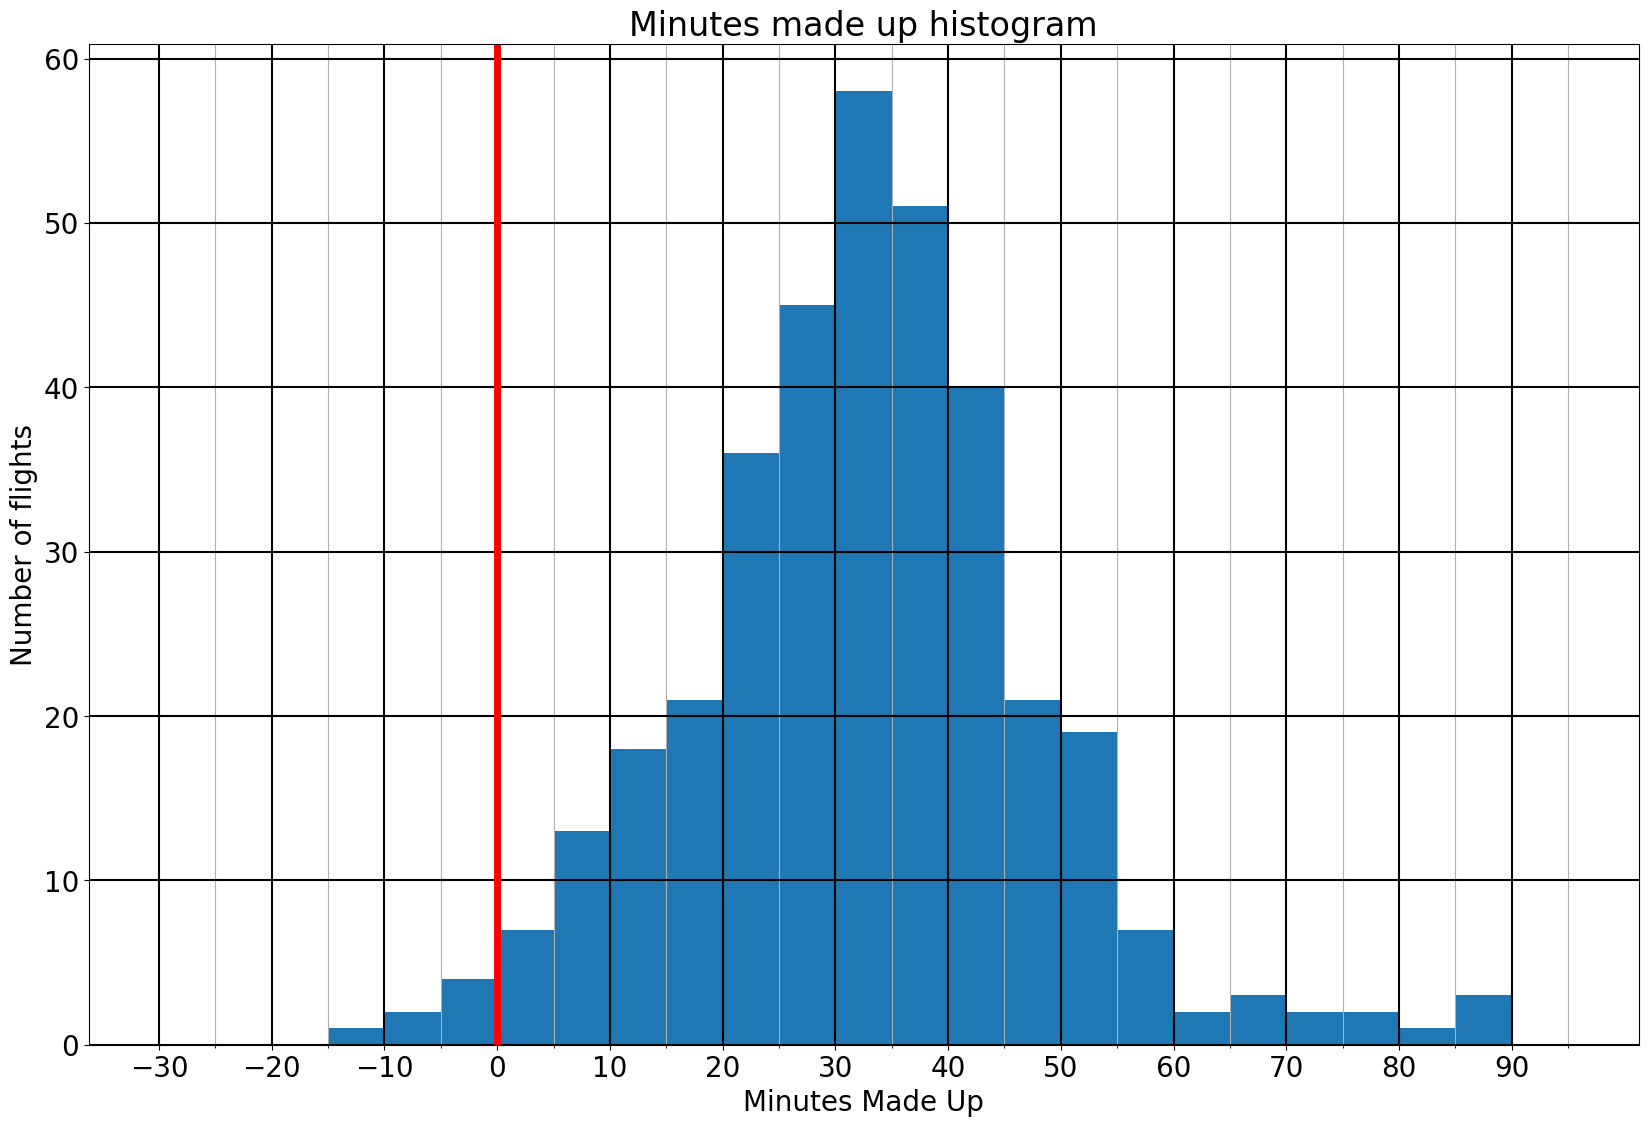

In [148]:
# Top flights in making up time
delay_cols = ['Scheduled Dep Time (Local)', 'Scheduled Arr Time (Local)', 'Actual Dep Time (Local)', 'Actual Arr Time (Local)', 'Scheduled Duration', 'Actual Duration', 'Airline', 'Flight', 'Dep Airport', 'Arr Airport', 'Dep Delay (min)', 'Arr Delay (min)', 'Minutes Made Up']

bins = list(range(-30, math.ceil(past_df['Minutes Made Up'].max()/10)*10+10, 5))
fig, ax = plt.subplots(figsize=(20,13))
ax.hist(past_df['Minutes Made Up'], bins=bins)
ax.set_xticks(bins, minor=True)
ax.set_xticks([b for i, b in enumerate(bins) if b%2 == 0])
ax.grid(which='major', linewidth=1.5, color='black')
ax.grid(which='minor', axis='both')
ax.set_xlabel('Minutes Made Up')
ax.set_ylabel('Number of flights')
ax.set_title('Minutes made up histogram')
ax.axvline(0, linewidth=5, color='red')
plt.savefig(ROOT_DIR + 'figures/minutes_made_up.jpg', bbox_inches='tight')

past_df.sort_values('Minutes Made Up', ascending=False).head(10)[delay_cols]


In [149]:
# Making up time by year

In [150]:
# Making up time by airline

# DEPARTURE/ARRIVAL TIMES

Morning flights (5a-12p): 118, 33%
Afternoon flights (12p-6p): 119, 33%
Evening flights (6p-11p): 100, 28%
Late nights flights (11p-5a): 23, 6%


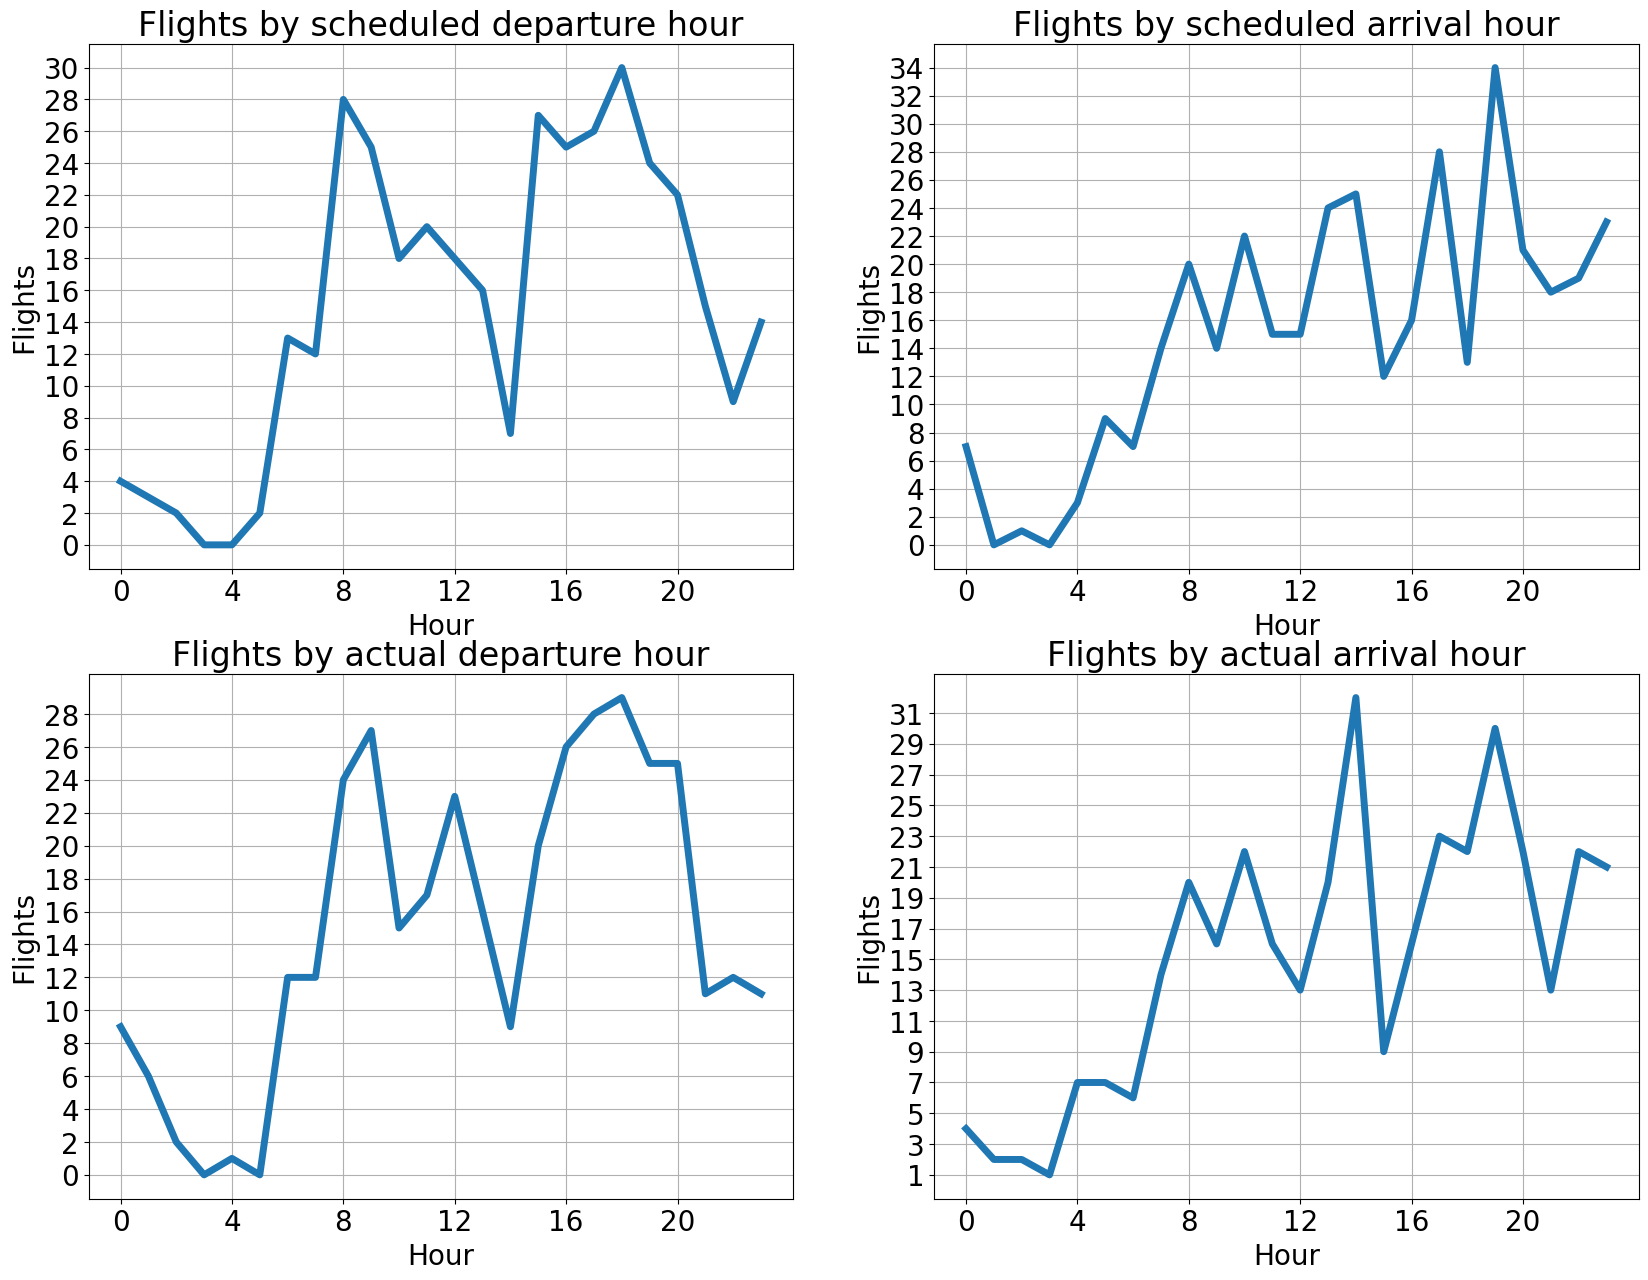

In [151]:
morning_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 5) & (df['Scheduled Dep Time (Local)'].dt.hour <= 11)].shape[0]
afternoon_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 12) & (df['Scheduled Dep Time (Local)'].dt.hour <= 17)].shape[0]
evening_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 18) & (df['Scheduled Dep Time (Local)'].dt.hour <= 22)].shape[0]
late_night_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 23) | (df['Scheduled Dep Time (Local)'].dt.hour <= 4)].shape[0]

print('Morning flights (5a-12p): ' + str(morning_flights) + ', ' + str(int(round(100*morning_flights/NUM_FLIGHTS))) + '%')
print('Afternoon flights (12p-6p): ' + str(afternoon_flights) + ', ' + str(int(round(100*afternoon_flights/NUM_FLIGHTS))) + '%')
print('Evening flights (6p-11p): ' + str(evening_flights) + ', ' + str(int(round(100*evening_flights/NUM_FLIGHTS))) + '%')
print('Late nights flights (11p-5a): ' + str(late_night_flights) + ', ' + str(int(round(100*late_night_flights/NUM_FLIGHTS))) + '%')

df['Scheduled dep hour'] = df['Scheduled Dep Time (Local)'].dt.hour
df['Scheduled arr hour'] = df['Scheduled Arr Time (Local)'].dt.hour
df['Actual dep hour'] = df['Actual Dep Time (Local)'].dt.hour
df['Actual arr hour'] = df['Actual Arr Time (Local)'].dt.hour

scheduled_dep_hour = df.groupby('Scheduled dep hour') .agg({'Date': 'count'}).reset_index().rename(columns={'Scheduled dep hour': 'Hour', 'Date': 'Count'})
for h in set(range(0, 24)) - set(scheduled_dep_hour['Hour']):
    scheduled_dep_hour = pd.concat([scheduled_dep_hour, pd.DataFrame({'Hour': h, 'Count': 0}, index=[0])])
scheduled_dep_hour = scheduled_dep_hour.sort_values(by='Hour')

scheduled_arr_hour = df.groupby('Scheduled arr hour').agg({'Date': 'count'}).reset_index().rename(columns={'Scheduled arr hour': 'Hour', 'Date': 'Count'})
for h in set(range(0, 24)) - set(scheduled_arr_hour['Hour']):
    scheduled_arr_hour = pd.concat([scheduled_arr_hour, pd.DataFrame({'Hour': h, 'Count': 0}, index=[0])])
scheduled_arr_hour = scheduled_arr_hour.sort_values(by='Hour')

actual_dep_hour = df.groupby('Actual dep hour').agg({'Date': 'count'}).reset_index().rename(columns={'Actual dep hour': 'Hour', 'Date': 'Count'})
for h in set(range(0, 24)) - set(actual_dep_hour['Hour']):
    actual_dep_hour = pd.concat([actual_dep_hour, pd.DataFrame({'Hour': h, 'Count': 0}, index=[0])])
actual_dep_hour = actual_dep_hour.sort_values(by='Hour')

actual_arr_hour = df.groupby('Actual arr hour').agg({'Date': 'count'}).reset_index().rename(columns={'Actual arr hour': 'Hour', 'Date': 'Count'})
for h in set(range(0, 24)) - set(actual_arr_hour['Hour']):
    actual_arr_hour = pd.concat([actual_arr_hour, pd.DataFrame({'Hour': h, 'Count': 0}, index=[0])])
actual_arr_hour = actual_arr_hour.sort_values(by='Hour')

fig, ax = plt.subplots(2, 2, figsize=(20,15))
ax[0, 0].plot(scheduled_dep_hour['Hour'], scheduled_dep_hour['Count'], linewidth=5)
ax[0, 0].grid(True)
ax[0, 0].set_xticks(range(0,24,4))
ax[0, 0].set_xlabel('Hour')
ax[0, 0].set_yticks(np.arange(min(scheduled_dep_hour['Count']), max(scheduled_dep_hour['Count'])+1, 2.0))
ax[0, 0].set_ylabel('Flights')
ax[0, 0].set_title('Flights by scheduled departure hour')

ax[1, 0].plot(actual_dep_hour['Hour'], actual_dep_hour['Count'], linewidth=5)
ax[1, 0].grid(True)
ax[1, 0].set_xticks(range(0,24,4))
ax[1, 0].set_xlabel('Hour')
ax[1, 0].set_yticks(np.arange(min(actual_dep_hour['Count']), max(actual_dep_hour['Count'])+1, 2.0))
ax[1, 0].set_ylabel('Flights')
ax[1, 0].set_title('Flights by actual departure hour')

ax[0, 1].plot(scheduled_arr_hour['Hour'], scheduled_arr_hour['Count'], linewidth=5)
ax[0, 1].grid(True)
ax[0, 1].set_xticks(range(0,24,4))
ax[0, 1].set_xlabel('Hour')
ax[0, 1].set_yticks(np.arange(min(scheduled_arr_hour['Count']), max(scheduled_arr_hour['Count'])+1, 2.0))
ax[0, 1].set_ylabel('Flights')
ax[0, 1].set_title('Flights by scheduled arrival hour')

ax[1, 1].plot(actual_arr_hour['Hour'], actual_arr_hour['Count'], linewidth=5)
ax[1, 1].grid(True)
ax[1, 1].set_xticks(range(0,24,4))
ax[1, 1].set_xlabel('Hour')
ax[1, 1].set_yticks(np.arange(min(actual_arr_hour['Count']), max(actual_arr_hour['Count'])+1, 2.0))
ax[1, 1].set_ylabel('Flights')
ax[1, 1].set_title('Flights by actual arrival hour')
plt.savefig(ROOT_DIR + 'figures/by_hour.jpg', bbox_inches='tight')



# ROUTES

In [152]:
#Augment routes

def get_hist(x):
    dct = {a: x.tolist().count(a) for a in x.tolist()}
    return ';'.join([str(list(dct.keys())[i]) + ',' + str(list(dct.values())[i]) for i in range(len(dct))])


def augment_routes(df):
    route_grouped = df.groupby('Sorted Route')
    df[['Class', 'Airline', 'Flight']] = df[['Class', 'Airline', 'Flight']].fillna('Unknown')
    df['route_date_string'] = route_grouped['Date'].transform(lambda x: ';'.join(str(a) for a in x))
    df['route_class_hist'] = route_grouped['Class'].transform(get_hist)#(lambda x: str(x.tolist().count('Economy')) + ',' + str(x.tolist().count('Business')))
    df['route_airline_hist'] = route_grouped['Airline'].transform(get_hist)
    df['route_flight_string'] = route_grouped['Flight'].transform(lambda x: ';'.join(x))
    df['route_origin_hist'] = route_grouped['Dep Airport'].transform(get_hist)
    grouped = df.groupby('Sorted Route').first()[['Distance', 'Actual Duration (min)', 'Domestic/International',
                                        'route_date_string', 'route_class_hist', 'route_airline_hist', 'route_flight_string', 'route_origin_hist'
                                       ]]
    grouped['count'] = grouped['route_date_string'].apply(lambda x: len(x.split(';')))

    grouped = grouped.reset_index()
    grouped['Dep IATA'] = grouped['Sorted Route'].apply(lambda x: x.split(' ')[0])
    grouped['Arr IATA'] = grouped['Sorted Route'].apply(lambda x: x.split(' ')[1])
    grouped = grouped.merge(airports[['IATA', 'Name', 'City', 'Country', 'Lat', 'Long']], left_on='Dep IATA', right_on='IATA', how='left')
    grouped = grouped.drop(columns='IATA').rename(columns={'Name': 'Dep Name', 'City': 'Dep City', 'Country': 'Dep Country', 'Lat': 'Dep Lat', 'Long': 'Dep Long'})
    grouped = grouped.merge(airports[['IATA', 'Name', 'City', 'Country', 'Lat', 'Long']], left_on='Arr IATA', right_on='IATA', how='left')
    grouped = grouped.drop(columns='IATA').rename(columns={'Name': 'Arr Name', 'City': 'Arr City', 'Country': 'Arr Country', 'Lat': 'Arr Lat', 'Long': 'Arr Long'})

    return grouped






In [153]:
routes = df.groupby(['Dep Airport', 'Arr Airport']).agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False)
routes.columns = ['Count', 'Total Distance']
routes.head(15)



/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1327263403.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  routes = df.groupby(['Dep Airport', 'Arr Airport']).agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False)


Count  Total Distance
Dep Airport Arr Airport                       
BOS         EWR             14            2814
EWR         BOS             12            2412
            PEK             10           68310
SFO         BOS              7           18928
PEK         EWR              5           34155
IAD         BOS              3            1239
PEK         SFO              3           17739
BOS         IAD              3            1239
EWR         SFO              3            7695
SFO         LHR              3           16104
BOS         ORD              3            2601
SFO         EWR              3            7695
PEK         IAD              3           20763
SIN         SFO              2           16892
PEK         NRT              2            2660

In [154]:
df['Sorted Route'] = df.apply(lambda row: str(sorted([row['Dep Airport'], row['Arr Airport']])[0]) + ' ' + str(sorted([row['Dep Airport'], row['Arr Airport']])[1]), axis=1)
routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False)
routes_sorted.columns = ['Count', 'Total Distance']
routes_sorted[routes_sorted['Count'] >=3].reset_index()

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2191246571.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum}).sort_values(by='Date', ascending=False)


,Sorted Route,Count,Total Distance
0,BOS EWR,26,5226
1,EWR PEK,15,102465
2,BOS SFO,9,24336
3,EWR SFO,6,15390
4,BOS IAD,6,2478
5,LHR SFO,4,21472
6,BOS DEN,4,7016
7,PEK SYX,4,6240
8,BOS PEK,4,26948
9,BOS ORD,4,3468


# AIRPORTS

In [155]:
# Augment airports

def augment_airports(df):
    df['Year'] = df['Date'].dt.year

    dep_grouped = df.groupby('Dep Airport')
    df['dep_dest_hist'] = dep_grouped['Arr Airport'].transform(get_hist)
    df['dep_count'] = dep_grouped['Date'].transform(lambda v: v.shape[0])
    df['dep_first'] = dep_grouped['Date'].transform(lambda v: min(v))
    df['dep_last'] = dep_grouped['Date'].transform(lambda v: max(v))
    df['dep_airline_hist'] = dep_grouped['Airline'].transform(get_hist)
    df['dep_intdom_hist'] = dep_grouped['Domestic/International'].transform(get_hist)
    df['dep_year_hist'] = dep_grouped['Year'].transform(get_hist)

    arr_grouped = df.groupby('Arr Airport')
    df['arr_dest_hist'] = arr_grouped['Dep Airport'].transform(get_hist)
    df['arr_count'] = arr_grouped['Date'].transform(lambda v: v.shape[0])
    df['arr_first'] = arr_grouped['Date'].transform(lambda v: min(v))
    df['arr_last'] = arr_grouped['Date'].transform(lambda v: max(v))
    df['arr_conn_count'] = arr_grouped['Arr Connect'].transform(lambda v: int(v.sum())).astype('int')
    df['arr_airline_hist'] = arr_grouped['Airline'].transform(get_hist)
    df['arr_intdom_hist'] = arr_grouped['Domestic/International'].transform(get_hist)
    df['arr_year_hist'] = arr_grouped['Year'].transform(get_hist)

    df['arr_conn_year_hist'] = df[df['Arr Connect'] == 1].groupby('Arr Airport')['Year'].transform(get_hist)

    df = df.drop(columns='arr_conn_year_hist').merge(df[['Arr Airport', 'arr_conn_year_hist']].dropna().drop_duplicates(), on='Arr Airport', how='left')

    deps = df.groupby('Dep Airport').first()[['Dep Name', 'Dep City', 'Dep Country', 'Dep Lat', 'Dep Long',
                                       'dep_dest_hist', 'dep_count', 'dep_first', 'dep_last', 'dep_airline_hist', 'dep_intdom_hist', 'dep_year_hist'
                                      ]].reset_index()
    arrcons = df.groupby('Arr Airport').first()[['Arr Name', 'Arr City', 'Arr Country', 'Arr Lat', 'Arr Long',
                                                 'arr_dest_hist', 'arr_count', 'arr_first', 'arr_last', 'arr_airline_hist', 'arr_intdom_hist', 'arr_year_hist',
                                       'arr_conn_count', 'arr_conn_year_hist'
                                      ]].reset_index()
    airports_aug = deps.merge(arrcons, left_on='Dep Airport', right_on='Arr Airport', how='outer')
    
    def merge_names(row):
        for col in ['Airport', 'Name', 'City', 'Country']:
            row[col] = row['Dep '+ col] if type(row['Dep '+ col]) == str else row['Arr '+ col]
        for col in ['Lat', 'Long']:
            row[col] = row['Dep '+ col] if not np.isnan(row['Dep '+ col]) else row['Arr '+ col]
        return row


    airports_aug = airports_aug.apply(merge_names, axis=1)
    airports_aug = airports_aug.rename(columns={'Airport': 'IATA'})

    airports_aug = airports_aug[['IATA', 'Name', 'City', 'Country', 'Lat', 'Long',
                                 'dep_count', 'arr_count', 'arr_conn_count',
                                 'dep_dest_hist', 'arr_dest_hist',
                                 'dep_first', 'arr_first', 'dep_last', 'arr_last',
                                 'dep_airline_hist', 'arr_airline_hist',
                                 'dep_intdom_hist', 'arr_intdom_hist',
                                 'dep_year_hist', 'arr_year_hist', 'arr_conn_year_hist'
                                ]]
    airports_aug['dep_count'] = airports_aug['dep_count'].fillna(0) - airports_aug['arr_conn_count'].fillna(0)
    airports_aug['arr_count'] = airports_aug['arr_count'].fillna(0) - airports_aug['arr_conn_count'].fillna(0)

    def subtract_hist(row):
        dep_hist = {int(x.split(',')[0]): int(x.split(',')[1]) for x in row['dep_year_hist'].split(';')} if row['dep_year_hist'] != '' else {}
        arr_hist = {int(x.split(',')[0]): int(x.split(',')[1]) for x in row['arr_year_hist'].split(';')} if row['arr_year_hist'] != '' else {}
        conn_hist = {int(x.split(',')[0]): int(x.split(',')[1]) for x in row['arr_conn_year_hist'].split(';')} if row['arr_conn_year_hist'] != '' else {}

        for year in conn_hist:
            if year in dep_hist:
                dep_hist[year] -= conn_hist[year]
            else:
                print(year, 'not in dep')
            if year in arr_hist:
                arr_hist[year] -= conn_hist[year]
            else:
                print(year, 'not in arr')

        row['dep_year_hist'] = ';'.join([str(x) + ',' + str(dep_hist[x]) for x in dep_hist if dep_hist[x] > 0])
        row['arr_year_hist'] = ';'.join([str(x) + ',' + str(arr_hist[x]) for x in arr_hist if arr_hist[x] > 0])
        full_year_hist = {}
        for key in dep_hist:
            full_year_hist[key] = full_year_hist[key] + dep_hist[key] if key in full_year_hist else dep_hist[key]
        for key in arr_hist:
            full_year_hist[key] = full_year_hist[key] + arr_hist[key] if key in full_year_hist else arr_hist[key]
        for key in conn_hist:
            full_year_hist[key] = full_year_hist[key] + conn_hist[key] if key in full_year_hist else conn_hist[key]
        row['full_year_hist'] = ';'.join([str(x) + ',' + str(full_year_hist[x]) for x in full_year_hist if full_year_hist[x] > 0])
        return row

    airports_aug[['dep_year_hist', 'arr_year_hist', 'arr_conn_year_hist']] = airports_aug[['dep_year_hist', 'arr_year_hist', 'arr_conn_year_hist']].fillna('')
    airports_aug = airports_aug.apply(subtract_hist, axis=1)
    airports_aug['total'] = airports_aug['dep_count'].fillna(0) + airports_aug['arr_count'].fillna(0) + airports_aug['arr_conn_count'].fillna(0)
    airports_aug['first'] = airports_aug.apply(lambda row: min(row['dep_first'], row['arr_first']), axis=1)
    airports_aug['last'] = airports_aug.apply(lambda row: min(row['dep_last'], row['arr_last']), axis=1)
    return airports_aug

all_airports_aug = augment_airports(df)


2024 not in dep


In [156]:
# Airports by visits
dep_countries = df.groupby(['Dep Country', 'Dep City', 'Dep Airport']).agg({'Date': 'count'}).reset_index()
dep_countries.columns = ['Country','City', 'Airport','Departures']
arr_countries = df.groupby(['Arr Country', 'Arr City', 'Arr Airport']).agg({'Date': 'count'}).reset_index()
arr_countries.columns = ['Country', 'City', 'Airport', 'Arrivals']
connect_countries = df[df['Arr Connect'] == 1].groupby(['Arr Country', 'Arr City', 'Arr Airport']).agg({'Date': 'count'}).reset_index()
connect_countries.columns = ['Country', 'City', 'Airport', 'Connections']
countries = pd.merge(pd.merge(dep_countries, arr_countries, how='outer'), connect_countries, how='outer').fillna(0).groupby(['Country', 'City', 'Airport']).agg({'Departures': 'first', 'Arrivals': 'first', 'Connections': 'first'})
countries['Total Visits'] = countries['Departures'] + countries['Arrivals'] - countries['Connections']
countries['Departures'] = countries['Departures'] - countries['Connections']
countries['Arrivals'] = countries['Arrivals'] - countries['Connections']
countries.astype('int32')

countries_sorted = countries.sort_values(by=['Total Visits'], ascending=False)
countries_sorted = countries_sorted.astype('int32')
countries_sorted.head(30)

Departures  Arrivals  Connections  \
Country        City              Airport                                      
United States  Boston            BOS              38        38            0   
China          Beijing           PEK              36        37            1   
United States  San Francisco Bay SFO              34        32            4   
               New York          EWR               9        10           23   
United Kingdom London            LHR               7        11            1   
                                 STN               7         5            0   
China          Beijing           PKX               6         4            0   
United States  Los Angeles       LAX               4         4            2   
China          Shanghai          PVG               3         4            1   
France         Paris             CDG               3         4            1   
United States  Philadelphia      PHL               4         4            0   
               Washington        IAD               0         0            7   
Singapore      Singapore         SIN               3         3            1   
United States  Chicago           ORD               2         2            3   
               Denver            DEN               1         1            5   
Hong Kong      Hong Kong         HKG               3         2            1   
China          Urumqi            URC               2         2            2   
Portugal       Lisbon            LIS               1         1            4   
United States  New York          JFK               2         2            2   
United Kingdom London            LGW               3         2            0   
United States  Honolulu          HNL               2         2            1   
               Houston           IAH               0         0            5   
               Las Vegas         LAS               1         2            1   
New Zealand    Auckland          AKL               2         2            0   
Turkey         Istanbul          IST               2         2            0   
South Korea    Seoul             ICN               2         2            0   
Germany        Frankfurt         FRA               1         1            2   
United States  Detroit           DTW               2         2            0   
Australia      Sydney            SYD               2         2            0   
China          Sanya             SYX               2         2            0   

                                          Total Visits  
Country        City              Airport                
United States  Boston            BOS                76  
China          Beijing           PEK                74  
United States  San Francisco Bay SFO                70  
               New York          EWR                42  
United Kingdom London            LHR                19  
                                 STN                12  
China          Beijing           PKX                10  
United States  Los Angeles       LAX                10  
China          Shanghai          PVG                 8  
France         Paris             CDG                 8  
United States  Philadelphia      PHL                 8  
               Washington        IAD                 7  
Singapore      Singapore         SIN                 7  
United States  Chicago           ORD                 7  
               Denver            DEN                 7  
Hong Kong      Hong Kong         HKG                 6  
China          Urumqi            URC                 6  
Portugal       Lisbon            LIS                 6  
United States  New York          JFK                 6  
United Kingdom London            LGW                 5  
United States  Honolulu          HNL                 5  
               Houston           IAH                 5  
               Las Vegas         LAS                 4  
New Zealand    Auckland          AKL                 4  
Turkey         Istanbul        

In [157]:
# Airport visits by city
airports_city = countries_sorted.reset_index().groupby('City').agg({'Departures': sum, 'Arrivals': sum, 'Connections': sum, 'Total Visits': sum, 'Airport': 'count'})
airports_city.sort_values(by='Total Visits', ascending=False).head(30)


/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1802388444.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  airports_city = countries_sorted.reset_index().groupby('City').agg({'Departures': sum, 'Arrivals': sum, 'Connections': sum, 'Total Visits': sum, 'Airport': 'count'})
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/1802388444.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  airports_city = countries_sorted.reset_index().groupby('City').agg({'Departures': sum, 'Arrivals': sum, 'Connections': sum, 'Total Visits': sum, 'Airport': 'count'})


,Departures,Arrivals,Connections,Total Visits,Airport
City,,,,,
Beijing,42,41,1,84,2
Boston,38,38,0,76,1
San Francisco Bay,36,35,4,75,3
New York,12,12,25,49,3
London,18,19,1,38,4
Los Angeles,4,4,2,10,1
Shanghai,5,4,1,10,2
Paris,3,4,1,8,1
Philadelphia,4,4,0,8,1


/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3894121322.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  airports_by_country = countries_sorted.reset_index().groupby('Country').agg({'Total Visits': sum, 'Airport': 'count'}).sort_values(by='Total Visits', ascending=False)


,Total Visits,Airport
Country,,
United States,289,30
China,140,27
United Kingdom,40,5
France,12,3
Spain,11,6
Japan,10,4
Italy,8,4
Portugal,8,2
Australia,8,3


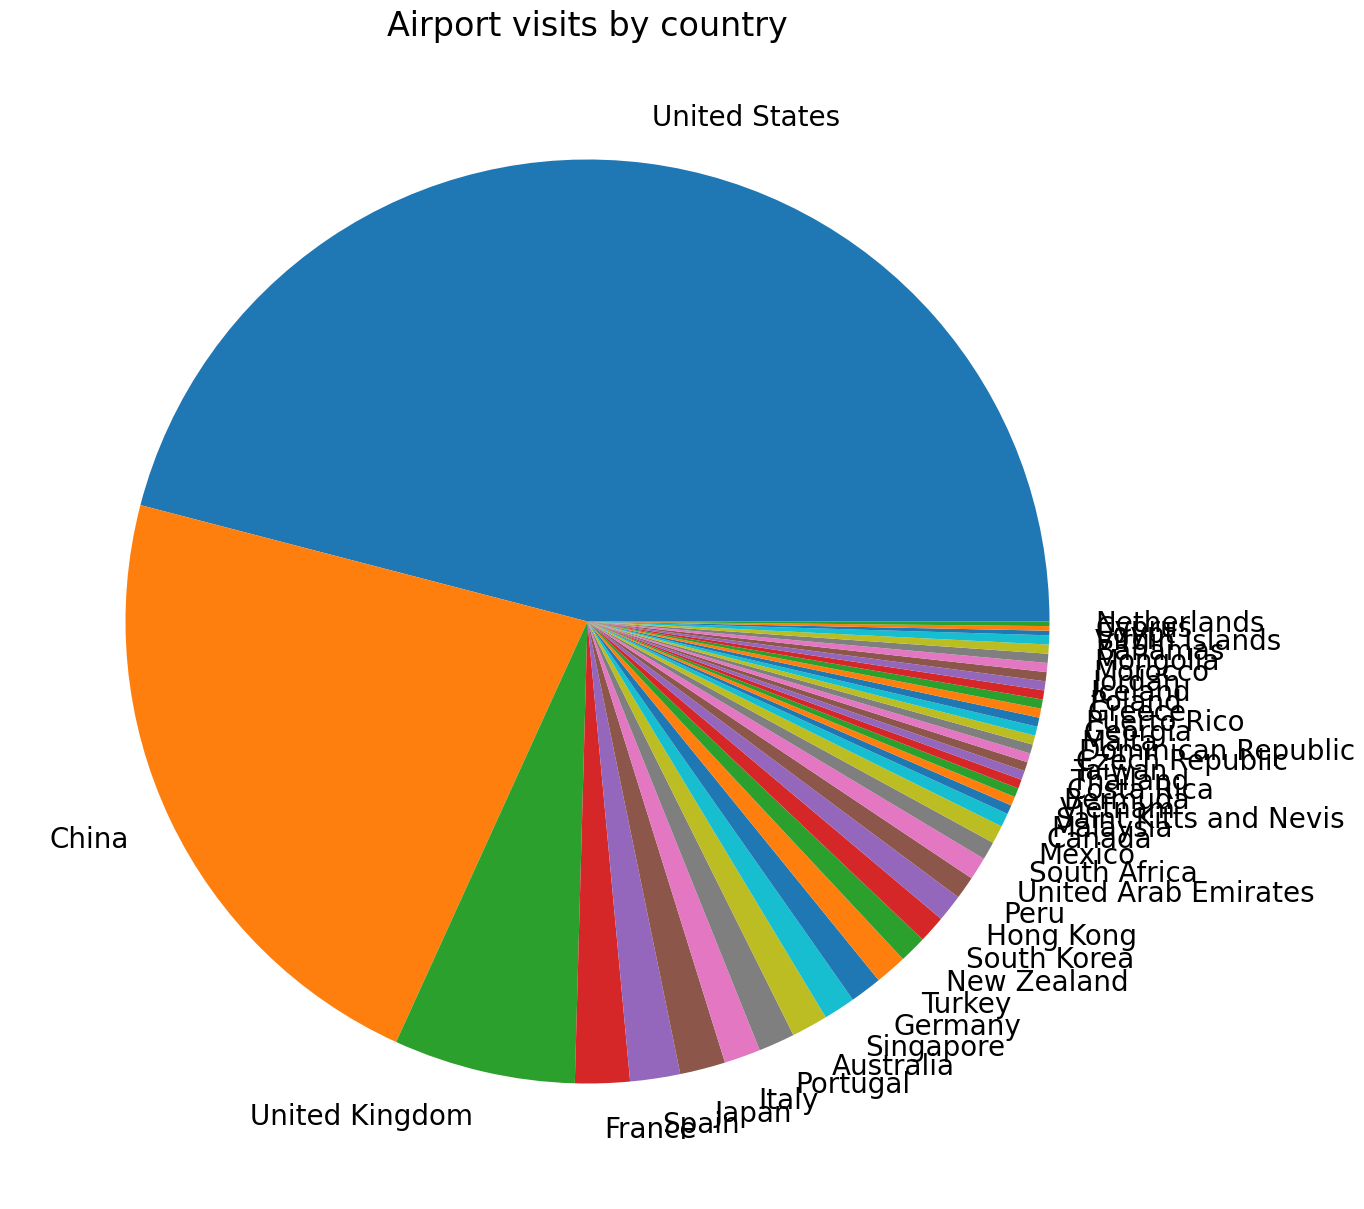

In [158]:
# Countries by visits
fig, ax = plt.subplots(1, 1, figsize=(15,15))
airports_by_country = countries_sorted.reset_index().groupby('Country').agg({'Total Visits': sum, 'Airport': 'count'}).sort_values(by='Total Visits', ascending=False)
airports_by_country.plot('Country', 'Total Visits', kind='pie', legend=False, ax=ax)
ax.set_title('Airport visits by country')
ax.set_ylabel('')
plt.savefig(ROOT_DIR + 'figures/countries.jpg', bbox_inches='tight')

airports_by_country.head(15)

In [159]:
# Airports by destinations
all_airports_aug['dep_dest_hist'] = all_airports_aug['dep_dest_hist'].fillna('')
all_airports_aug['arr_dest_hist'] = all_airports_aug['arr_dest_hist'].fillna('')
all_airports_aug = all_airports_aug.fillna(0)
all_airports_aug['dests'] = all_airports_aug.apply(lambda row: 
                                                       ','.join(sorted(set([t.split(',')[0] for t in (row['dep_dest_hist'] + row['arr_dest_hist']).split(';')]))), 
                                                       axis=1)
all_airports_aug['dests_count'] = all_airports_aug.apply(lambda row: len(row['dests'].split(',')), axis=1)

all_airports_aug['visit_count'] = (all_airports_aug['dep_count'] + all_airports_aug['arr_count'] + all_airports_aug['arr_conn_count']).astype(int)

all_airports_aug[['IATA', 'City', 'Country', 'visit_count', 'dests', 'dests_count']].sort_values(by='dests_count', ascending=False).head(15)


,IATA,City,Country,visit_count,dests,dests_count
82,PEK,Beijing,China,74,"BOS,CAI,CGQ,CKG,DXB,DYG,EWR,GMP,HGH,HKG,HND,HR...",38
98,SFO,San Francisco Bay,United States,70,"AKL,AUS,BOS,EWR,FRA,HKG,HNL,IAD,IAH,ICN,JFK,KI...",32
32,EWR,New York,United States,42,"BOS,CPT,DTW,FRA,IST,LAX,LHR,LIM,LIS,MEX,NAS,NR...",19
14,BOS,Boston,United States,76,"CDG,DEN,DTW,EWR,FRA,IAD,IAH,JFK,KEF,LAX,LHR,LI...",19
60,LHR,London,United Kingdom,19,"AGP,AUH,BOS,BSL,CDG,EWR,FRA,LAX,PEK,SFO,TBS,WAW",12
56,LAX,Los Angeles,United States,10,"BOS,DEN,EWR,IAD,LAS,LHR,ORD,SFO,SYD",9
86,PKX,Beijing,China,10,"AUH,CAN,CSX,HGH,HJJ,PVG,URC,XMN",8
108,STN,London,United Kingdom,12,"FAO,MLA,NAP,OZZ,PRG,SAW,TRS,VLC",8
91,PVG,Shanghai,China,8,"ATH,BOS,CAN,HKG,HND,PEK,PKX",7
64,LIS,Lisbon,Portugal,6,"EWR,FCO,LGW,MAD,MUC,SFO",6


# STUFF FOR WEB

In [160]:
#### MAKE AIRPORTS AND ROUTES

def make_airport_geojson(df, path):
    airports_aug = augment_airports(df)
    for col in ['dep_first', 'arr_first', 'dep_last', 'arr_last', 'first', 'last']:
        airports_aug[col] = airports_aug[col].dt.strftime('%Y-%m-%d')
    airports_aug = airports_aug.fillna('')
    features = []
    for i, row in airports_aug.iterrows():
#         print(row.drop(['Lat', 'Long']).to_dict())
        features.append(Feature(geometry=Point((row['Long'], row['Lat'])), properties=row.drop(['Lat', 'Long']).to_dict()))
    fc = FeatureCollection(features)
    with open(path, 'w') as f:
        dump(fc, f)
    return airports_aug
        

def get_path(startlong, startlat, endlong, endlat):
    # calculate distance between points
    g = pyproj.Geod(ellps='WGS84')
    (az12, az21, dist) = g.inv(startlong, startlat, endlong, endlat)

    # calculate line string along path with segments <= 1 km
    lonlats = g.npts(startlong, startlat, endlong, endlat,
                     1 + int(dist / 5000))
    
    # npts doesn't include start/end points, so prepend/append them
    lonlats.insert(0, (startlong, startlat))
    lonlats.append((endlong, endlat))
    offset = 0
    for i in range(len(lonlats)-1):
        if lonlats[i][0] > 0 and lonlats[i+1][0] < 0 and lonlats[i+1][0] < -170:
            offset = 360
        elif lonlats[i][0] < 0 and lonlats[i+1][0] > 0 and lonlats[i+1][0] > 170:
            offset = -360
        lonlats[i+1] = (lonlats[i+1][0] + offset , lonlats[i+1][1])
#     print(len(lonlats))
    return LineString(lonlats)


def make_route_geojson(df, path):
    
    grouped = augment_routes(df)
    
    features = []
    for i, row in grouped.iterrows():
    #     lats = row['Sorted Lat'].split(';')
    #     longs = row['Sorted Long'].split(';')
        properties = properties = {'start_iata': row['Dep IATA'], 
                              'start_name': row['Dep Name'], 
                              'start_city_country': row['Dep City'] + ', ' + row['Dep Country'], 
                              'end_iata': row['Arr IATA'], 
                              'end_name': row['Arr Name'], 
                              'end_city_country': row['Arr City'] + ', ' + row['Arr Country'],  
                              'dist': row['Distance'], 
                              'dur': row['Actual Duration (min)'],
                              'domint': row['Domestic/International'],
                              'count': row['count'],
                              'earliest_date': row['route_date_string'].split(';')[0].split(' ')[0],
                              'latest_date': row['route_date_string'].split(';')[-1].split(' ')[0],
                              'date_string': row['route_date_string'],
                              'class_hist': row['route_class_hist'],
                              'airline_hist': row['route_airline_hist'],
                              'flight_string': row['route_flight_string'],
                              'origin_hist': row['route_origin_hist']
                             }
        features.append(Feature(geometry=get_path(row['Dep Long'], row['Dep Lat'], 
                                                  row['Arr Long'], row['Arr Lat']),
                                properties = properties))
    fc = FeatureCollection(features)

    with open(path, 'w') as f:
        dump(fc, f)


make_route_geojson(df, ROOT_DIR + 'routes_all.geojson')
make_airport_geojson(df, ROOT_DIR + 'airports_all.geojson')

all_years = df['Date'].dt.year.unique().tolist()
first_month = min(df[df['Date'].dt.year == all_years[0]]['Date'].dt.month)
last_month = max(df[df['Date'].dt.year == all_years[-1]]['Date'].dt.month)

with open(ROOT_DIR + "month_range.txt", "w") as text_file:
    text_file.write(','.join(str(x) for x in all_years) + '\n' + str(first_month) + ',' + str(last_month))

year_airports_aug = {}
for year in all_years:
    make_route_geojson(df[df['Date'].dt.year == year], ROOT_DIR + 'routes_' + str(year) + '.geojson')
    year_airports_aug[year] = make_airport_geojson(df[df['Date'].dt.year == year], ROOT_DIR + 'airports_' + str(year) + '.geojson')

print('years done')

for year in all_years:
    print(year)
    for month in range(1, 13):
        if year == all_years[0] and month < first_month:
            continue
        if year == all_years[-1] and month > last_month:
            continue
        print('  ', month)
        simp_df = pd.concat([df[df['Date'].dt.year < year], df[df['Date'].dt.year == year][df['Date'].dt.month <= month]], ignore_index=True)
        make_route_geojson(simp_df, ROOT_DIR + 'routes_cum_' + str(year) + '_' + str(month) + '.geojson')
        make_airport_geojson(simp_df, ROOT_DIR + 'airports_cum_' + str(year) + '_' + str(month) + '.geojson')
    


2024 not in dep


/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3959819416.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Class', 'Airline', 'Flight']] = df[['Class', 'Airline', 'Flight']].fillna('Unknown')
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3959819416.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['route_date_string'] = route_grouped['Date'].transform(lambda x: ';'.join(str(a) for a in x))
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/39

2024 not in dep
years done
2015
   1


/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3949066760.py:101: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  simp_df = pd.concat([df[df['Date'].dt.year < year], df[df['Date'].dt.year == year][df['Date'].dt.month <= month]], ignore_index=True)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3949066760.py:101: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  simp_df = pd.concat([df[df['Date'].dt.year < year], df[df['Date'].dt.year == year][df['Date'].dt.month <= month]], ignore_index=True)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3949066760.py:101: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  simp_df = pd.concat([df[df['Date'].dt.year < year], df[df['Date'].dt.year == year][df['Date'].dt.month <= month]], ignore_index=True)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3949066760.py:101: UserWarning: Boolean Series 

   2
   3
   4
   5
   6
   7
   8
   9
   10
   11
   12


...

2024 not in dep
   3


/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3949066760.py:101: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  simp_df = pd.concat([df[df['Date'].dt.year < year], df[df['Date'].dt.year == year][df['Date'].dt.month <= month]], ignore_index=True)


2024 not in dep
   4


/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/3949066760.py:101: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  simp_df = pd.concat([df[df['Date'].dt.year < year], df[df['Date'].dt.year == year][df['Date'].dt.month <= month]], ignore_index=True)


2024 not in dep


# PRINTING

In [161]:
def get_stats(df, airports_aug, year=None, ab=False):
    print(year)
    TOTAL_DIST = df['Distance'].sum()
    TOTAL_TIME = df['Actual Duration (min)'].sum()
    NUM_FLIGHTS = df['Date'].count()
    NUM_AIRLINES = df['Airline'].nunique()
    NUM_COUNTRIES = len(set(df['Dep Country'].tolist()) | set(df['Arr Country'].tolist()))
    NUM_AIRPORTS = len(set(df['Dep Airport'].tolist()) | set(df['Arr Airport'].tolist()))

    dep_countries = df.groupby(['Dep Country', 'Dep Airport']).agg({'Date': 'count'}).reset_index()
    dep_countries.columns = ['Country', 'Airport', 'Departures']
    arr_countries = df.groupby(['Arr Country', 'Arr Airport']).agg({'Date': 'count'}).reset_index()
    arr_countries.columns = ['Country', 'Airport', 'Arrivals']
    countries = pd.merge(dep_countries, arr_countries, how='outer').fillna(0).groupby(['Country', 'Airport']).agg({'Departures': 'first', 'Arrivals': 'first'})
    countries['Total Dep/Arr'] = countries['Departures'] + countries['Arrivals']

    routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
    routes_sorted.columns = ['Count', 'Total Distance', 'Actual Duration (min)']

    airlines = df.groupby(['Airline']).agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
    airlines.columns = ['Count', 'Total Distance', 'Actual Duration (min)']

    dist_year = df.groupby(df['Date'].dt.year).agg({'Distance': sum, 'Date': 'count', 'Actual Duration (min)': sum})
    dist_year.columns = ['Distance', 'Flights', 'Actual Duration (min)']

    dom_int = df.groupby('Domestic/International').agg({'Distance': sum, 'Date': 'count', 'Actual Duration (min)': sum})
    dom_int.columns = ['Distance', 'Flights', 'Actual Duration (min)']

    clas = df.groupby('Class').agg({'Distance': sum, 'Date': 'count', 'Actual Duration (min)': sum})
    clas.columns = ['Distance', 'Flights', 'Actual Duration (min)']
   
    early_arrivals = df[df['Arr Delay (min)'] < 0].shape[0]
    on_time_arrivals = df[(df['Arr Delay (min)'] >= 0) & (df['Arr Delay (min)'] < 15)].shape[0]
    late_arrivals = df[(df['Arr Delay (min)'] >= 15) & (df['Arr Delay (min)'] < 60)].shape[0]
    really_late_arrivals = df[df['Arr Delay (min)'] >= 60].shape[0]

    morning_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 5) & (df['Scheduled Dep Time (Local)'].dt.hour <= 11)].shape[0]
    afternoon_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 12) & (df['Scheduled Dep Time (Local)'].dt.hour <= 17)].shape[0]
    evening_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 18) & (df['Scheduled Dep Time (Local)'].dt.hour <= 22)].shape[0]
    late_night_flights = df[(df['Scheduled Dep Time (Local)'].dt.hour >= 23) | (df['Scheduled Dep Time (Local)'].dt.hour <= 4)].shape[0]

    def get_time(minutes):
        return [int(minutes//60), int(minutes % 60)]

    def get_time_str(minutes):
        if get_time(minutes)[0] == 0:
            return str(get_time(minutes)[1]) + 'min'
        else:
            return str(get_time(minutes)[0]) + 'h ' + str(get_time(minutes)[1]) + 'm'

        
    big_str = ''
    if ab:
        big_str += '<h2><span class=\'bold\'>Alex\'s Flight Log (' + str(first_month) + '/' + str(all_years[0]) + '-' + str(last_month) + '/' + str(all_years[-1]) + ')</span></h2>'
    else:
        big_str += '<h2><span class=\'bold\'>Alex\'s Flight Log (' + str(year) + ')</span></h2>'
        
    big_str += '<p>Total Distance Flown: <span class=\'bold\'>' + '{:,}'.format(TOTAL_DIST).split('.')[0] + '</span>mi' + '\n'
    big_str += '<br>Total Time in Air: <span class=\'bold\'>' + str(timedelta(minutes=int(TOTAL_TIME))) + '</span>' + '\n'
    big_str += '<br>Total Flights: <span class=\'bold\'>' + str(NUM_FLIGHTS) + '</span>' + '\n'
    big_str += '<br>Number of Airlines: <span class=\'bold\'>' + str(NUM_AIRLINES) + '</span>'
    big_str += ', Countries: <span class=\'bold\'>' + str(NUM_COUNTRIES) + '</span>'
    big_str += ', Airports: <span class=\'bold\'>' + str(NUM_AIRPORTS) + '</span>' + '\n'
    big_str += '<p>Longest interval between flights: <span class=\'bold\'>' + str(LONGEST_INTERVAL) + '</span> (' + str(LONGEST_INTERVAL_0) + ' to ' + str(LONGEST_INTERVAL_1) + ')\n'
    big_str += '<br>Month with most flying: <span class=\'bold\'>' 
    big_str += str(a.sort_values('Flights', ascending=False).reset_index().loc[0, 'Y-M']) + '</span> (' 
    big_str += str(int(a.sort_values('Flights', ascending=False).reset_index().loc[0, 'Flights'])) + ' flights, '
    big_str += get_time_str(a.sort_values('Flights', ascending=False).reset_index().loc[0, 'Actual Duration (min)']) + ') or <span class=\'bold\'>'
    big_str += str(a.sort_values('Actual Duration (min)', ascending=False).reset_index().loc[0, 'Y-M']) + '</span> (' 
    big_str += str(int(a.sort_values('Actual Duration (min)', ascending=False).reset_index().loc[0, 'Flights'])) + ' flights, '
    big_str += get_time_str(a.sort_values('Actual Duration (min)', ascending=False).reset_index().loc[0, 'Actual Duration (min)']) + ')\n'


    by_dist = df[df['Actual Duration (min)'] != 0.0].sort_values(by='Actual Duration (min)')
    print(by_dist)
    big_str += ('<p>Shortest flight: <span class=\'bold\'>' + by_dist.iloc[0]['Dep Airport'] + '</span> to <span class=\'bold\'>' + by_dist.iloc[0]['Arr Airport'] + '</span>' 
                + ' (' + '{:,}'.format(by_dist.iloc[0]['Distance']).split('.')[0] + 'mi, ' + get_time_str(by_dist.iloc[0]['Actual Duration (min)']) + ')' + '\n')


    by_dist2 = df.sort_values(by='Actual Duration (min)', ascending=False)
    big_str += ('<br>Longest flight: <span class=\'bold\'>' + by_dist2.iloc[0]['Dep Airport'] + '</span> to <span class=\'bold\'>' + by_dist2.iloc[0]['Arr Airport'] + '</span>' 
                + ' (' + '{:,}'.format(by_dist2.iloc[0]['Distance']).split('.')[0] + 'mi, ' + get_time_str(by_dist2.iloc[0]['Actual Duration (min)']) + ')</p>' + '\n')

    countries_list = countries.reset_index().groupby('Country').count().reset_index()[['Country', 'Airport']].sort_values(by='Airport', ascending=False).values.tolist()
    country_airport = '<p>Airport distribution (top countries): '
    for country, airports in countries_list[:5]:
        country_airport += '<span class=\'bold\'>' + country + '</span>: ' + str(airports) + ', '
    country_airport = country_airport[:-2]
    big_str += country_airport + '\n'

    # visited_airports
    visited_list = airports_aug.sort_values(by='total', ascending=False)[['IATA', 'total']].values.tolist()
    visited_airports = '<br>Airports by total visits: '
    for airport, total in visited_list[:5]:
        visited_airports += '<span class=\'bold\'>' + airport + '</span>: ' + str(int(total)) + ', '
    visited_airports = visited_airports[:-2]
    big_str += visited_airports + '\n'

    routes_list = routes_sorted.reset_index()[['Sorted Route', 'Count']].values.tolist()
    top_routes = '<br>Top routes: '
    for route, count in routes_list[:5]:
        top_routes += '<span class=\'bold\'>' + route.split(' ')[0] + '</span> to <span class=\'bold\'>' + route.split(' ')[1] + '</span>: ' + str(int(count)) + ', '
    top_routes = top_routes[:-2]
    big_str += top_routes + '\n'

    airlines_list = airlines.reset_index()[['Airline', 'Count']].values.tolist()
    top_airlines = '<br>Top airlines: '
    for airline, count in airlines_list[:5]:
        top_airlines += '<span class=\'bold\'>' + airline + '</span>: ' + str(int(count)) + ', '
    top_airlines = top_airlines[:-2]
    big_str += top_airlines + '\n'

    big_str += '<p>Early arrivals: <span class=\'bold\'>' + str(early_arrivals) + '</span> (' + str(round(100*early_arrivals/NUM_FLIGHTS))+'%)\n'
    big_str += '<br>On-time arrivals (within 15min): <span class=\'bold\'>' + str(on_time_arrivals) + '</span> (' + str(round(100*on_time_arrivals/NUM_FLIGHTS))+'%)\n'
    big_str += '<br>Late arrivals (up to 1hr delay): <span class=\'bold\'>' + str(late_arrivals) + '</span> (' + str(round(100*late_arrivals/NUM_FLIGHTS))+'%)\n'
    big_str += '<br>Really late arrivals (>1hr delay): <span class=\'bold\'>' + str(really_late_arrivals) + '</span> (' + str(round(100*really_late_arrivals/NUM_FLIGHTS))+'%)\n'
    big_str += '</p>\n'
    
    big_str += '<p>Morning flights (5am-12p): <span class=\'bold\'>' + str(morning_flights) + '</span> (' + str(round(100*morning_flights/NUM_FLIGHTS))+'%)\n'
    big_str += '<br>Afternoon flights (12p-6p): <span class=\'bold\'>' + str(afternoon_flights) + '</span> (' + str(round(100*afternoon_flights/NUM_FLIGHTS))+'%)\n'
    big_str += '<br>Evening flights (6p-11p): <span class=\'bold\'>' + str(evening_flights) + '</span> (' + str(round(100*evening_flights/NUM_FLIGHTS))+'%)\n'
    big_str += '<br>Late night flights (11p-5a): <span class=\'bold\'>' + str(late_night_flights) + '</span> (' + str(round(100*late_night_flights/NUM_FLIGHTS))+'%)\n'
    big_str += '</p>\n'
    
    dom_int_list = dom_int.reset_index()[['Domestic/International', 'Distance', 'Flights']].values.tolist()
    domint = '<p>'
    for di, dist, count in dom_int_list:
        domint += '<span class=\'bold\'>' + di + '</span>: ' + '{:,}'.format(dist).split('.')[0] + 'mi, ' + str(int(count)) + ' flights\n<br>'
    domint = domint[:-5] + '</p>'
    big_str += domint + '\n'

    class_list = clas.reset_index()[['Class', 'Distance', 'Flights']].values.tolist()
    class_str = '<p>'
    for c, dist, count in class_list:
        class_str += '<span class=\'bold\'>' + c + '</span>: ' + '{:,}'.format(dist).split('.')[0] + 'mi, ' + str(int(count)) + ' flights\n<br>'
    class_str = class_str[:-5] + '</p>'
    big_str += class_str + '\n'
    
    if ab: # ind years don't need this
        print(dist_year.reset_index())
        years_list = dist_year.reset_index()[['Date', 'Distance', 'Flights', 'Actual Duration (min)']].values.tolist()
        years = '<p>'
        for year, dist, count, dur in years_list:
            years += '<span class=\'bold\'>' + str(int(year)) + '</span>: ' + get_time_str(dur) + ', ' + str(int(count)) + ' flights, ' + '{:,}'.format(dist).split('.')[0] + 'mi \n<br>'
        years = years[:-5] + '</p>'
        big_str += years + '\n'

#     print(big_str)
    return big_str

big_str = get_stats(df, all_airports_aug, ab=True)
with open(ROOT_DIR + "all_stats.txt", "w") as text_file:
    text_file.write(big_str)
for i, year in enumerate(all_years):
    big_str = get_stats(df[df['Date'].dt.year == year], year_airports_aug[year], year=year)
    with open(ROOT_DIR + str(year) + "_stats.txt", "w") as text_file:
        text_file.write(big_str)

None
          Date Scheduled Dep Time (Local) Scheduled Arr Time (Local)  \
303 2024-07-01        2024-07-01 14:35:00        2024-07-01 15:18:00   
65  2017-11-13        2017-11-13 06:00:00        2017-11-13 07:03:00   
194 2022-01-03        2022-01-03 18:10:00        2022-01-03 19:10:00   
58  2017-09-22        2017-09-22 08:30:00        2017-09-22 09:32:00   
142 2020-05-20        2020-05-20 18:30:00        2020-05-20 19:48:00   
59  2017-09-24        2017-09-24 17:05:00        2017-09-24 18:25:00   
38  2017-03-20        2017-03-20 21:52:00        2017-03-20 23:05:00   
111 2019-07-08        2019-07-08 08:00:00        2019-07-08 09:18:00   
244 2023-04-22        2023-04-22 08:15:00        2023-04-22 09:30:00   
66  2017-11-13        2017-11-13 09:00:00        2017-11-13 10:24:00   
118 2019-09-28        2019-09-28 20:30:00        2019-09-28 21:47:00   
27  2016-12-15        2016-12-15 09:15:00        2016-12-15 10:35:00   
4   2015-03-19        2015-03-19 20:32:00        2015-03-19

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2360708355.py:17: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2360708355.py:20: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  airlines = df.groupby(['Airline']).agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/23607

2019
          Date Scheduled Dep Time (Local) Scheduled Arr Time (Local)  \
111 2019-07-08        2019-07-08 08:00:00        2019-07-08 09:18:00   
118 2019-09-28        2019-09-28 20:30:00        2019-09-28 21:47:00   
105 2019-05-24        2019-05-24 09:00:00        2019-05-24 10:19:00   
108 2019-06-01        2019-06-01 16:10:00        2019-06-01 17:15:00   
117 2019-09-26        2019-09-26 11:00:00        2019-09-26 12:23:00   
125 2019-12-18        2019-12-18 16:00:00        2019-12-18 17:44:00   
127 2019-12-20        2019-12-20 07:10:00        2019-12-20 08:20:00   
102 2019-03-28        2019-03-28 15:20:00        2019-03-28 16:50:00   
121 2019-11-28        2019-11-28 05:55:00        2019-11-28 07:35:00   
103 2019-03-31        2019-03-31 10:35:00        2019-03-31 12:10:00   
123 2019-12-02        2019-12-02 06:30:00        2019-12-02 09:05:00   
112 2019-07-26        2019-07-26 18:29:00        2019-07-26 22:00:00   
113 2019-07-29        2019-07-29 08:30:00        2019-07-29

/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2360708355.py:17: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  routes_sorted = df.groupby('Sorted Route').agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/2360708355.py:20: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  airlines = df.groupby(['Airline']).agg({'Date': 'count', 'Distance': sum, 'Actual Duration (min)': sum}).sort_values(by='Date', ascending=False)
/var/folders/gq/4z9x23w55k530vrnxr1wb2b00000gn/T/ipykernel_13497/23607

In [162]:
# Checking code

##### Code to check duration ######

# Convert durations to datetime object. DELETE AFTER CLEAN
# for col in ['Scheduled Difference', 'Actual Difference']:
#     df[col] = df[col].fillna('00:00')
#     df[col] = df[col].apply(lambda x: f'{x}:00')
#     df[col] = pd.to_timedelta(df[col])

# # Delete section after clean
# non_matching_scheduled = df[df['Scheduled Duration'] != df['Scheduled Difference']]
# non_matching_actual = df[df['Actual Duration'] != df['Actual Difference']]
# if (not non_matching_scheduled.empty):
#     print(non_matching_scheduled[['Date', 'Flight', 'Scheduled Duration', 'Scheduled Difference']])
# if (not non_matching_actual.empty):
#     print(non_matching_actual[['Date', 'Flight', 'Actual Duration', 'Actual Difference']])

####################################